<a href="https://www.kaggle.com/code/lalit7881/social-media-impact-on-teen-behaviour-eda-97?scriptVersionId=331449130" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abdulmaliklodhra/social-media-impact-on-teen-behaviour-2015-2060/region_2026_risk_profile.csv
/kaggle/input/datasets/abdulmaliklodhra/social-media-impact-on-teen-behaviour-2015-2060/global_forecast_2030_2040_2050_2060.csv
/kaggle/input/datasets/abdulmaliklodhra/social-media-impact-on-teen-behaviour-2015-2060/country_year_summary_2015_2060.csv
/kaggle/input/datasets/abdulmaliklodhra/social-media-impact-on-teen-behaviour-2015-2060/country_2026_risk_profile.csv
/kaggle/input/datasets/abdulmaliklodhra/social-media-impact-on-teen-behaviour-2015-2060/model_feature_importance.csv
/kaggle/input/datasets/abdulmaliklodhra/social-media-impact-on-teen-behaviour-2015-2060/global_teen_social_media_behaviour_464k_2015_2060_synthetic.csv
/kaggle/input/datasets/abdulmaliklodhra/social-media-impact-on-teen-behaviour-2015-2060/regional_urban_rural_risk_summary_2026.csv
/kaggle/input/datasets/abdulmaliklodhra/social-media-impact-on-teen-behaviour-2015-2060/teen_behaviour_segments.cs

## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/abdulmaliklodhra/social-media-impact-on-teen-behaviour-2015-2060/global_teen_social_media_behaviour_464k_2015_2060_synthetic.csv")

In [3]:
df.head()

,record_id,country,continent,region,income_group,year,age,age_group,gender,urban_rural,...,forecast_addiction_risk_2030,forecast_addiction_risk_2040,forecast_mental_health_risk_2030,forecast_mental_health_risk_2040,synthetic_data_flag,screen_time_category,sleep_category,problematic_use_flag,high_mental_health_risk_flag,high_academic_risk_flag
0,1,United Kingdom,Europe,Western Europe,High,2048,19,16-19,Male,Urban,...,72.00,72.00,55.44,55.44,1,High,Healthy,1,0,0
1,2,Denmark,Europe,Northern Europe,High,2055,19,16-19,Male,Rural,...,77.04,77.04,55.73,55.73,1,Extreme,Low,1,0,0
2,3,Rwanda,Africa,Sub-Saharan Africa,Low,2041,19,16-19,Male,Semi-urban,...,31.90,31.90,34.06,34.06,1,High,Low,0,0,0
3,4,Iran,Asia,Middle East,Lower-middle,2034,19,16-19,Male,Rural,...,58.65,61.95,43.32,45.60,1,High,Low,0,0,0
4,5,Qatar,Asia,Middle East,High,2015,18,16-19,Male,Urban,...,41.16,45.16,41.10,43.85,1,Moderate,Low,0,0,0


In [4]:
df.tail()

,record_id,country,continent,region,income_group,year,age,age_group,gender,urban_rural,...,forecast_addiction_risk_2030,forecast_addiction_risk_2040,forecast_mental_health_risk_2030,forecast_mental_health_risk_2040,synthetic_data_flag,screen_time_category,sleep_category,problematic_use_flag,high_mental_health_risk_flag,high_academic_risk_flag
464742,464743,Turkey,Asia/Europe,Middle East,Upper-middle,2031,13,13-15,Female,Rural,...,41.12,46.07,31.53,34.95,1,High,Low,0,0,0
464743,464744,Mozambique,Africa,Sub-Saharan Africa,Low,2033,10,10-12,Female,Urban,...,41.98,45.83,27.31,29.97,1,High,Low,0,0,0
464744,464745,Brazil,South America,Latin America,Upper-middle,2044,14,13-15,Male,Urban,...,48.71,48.71,38.01,38.01,1,High,Healthy,0,0,0
464745,464746,Peru,South America,Latin America,Upper-middle,2024,16,16-19,Female,Semi-urban,...,44.56,49.46,44.00,47.38,1,Moderate,Low,0,0,0
464746,464747,Panama,North America,Latin America,High,2023,11,10-12,Male,Semi-urban,...,76.32,81.12,52.19,55.50,1,High,Low,1,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464747 entries, 0 to 464746
Data columns (total 87 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   record_id                           464747 non-null  int64  
 1   country                             464747 non-null  object 
 2   continent                           464747 non-null  object 
 3   region                              464747 non-null  object 
 4   income_group                        464747 non-null  object 
 5   year                                464747 non-null  int64  
 6   age                                 464747 non-null  int64  
 7   age_group                           464747 non-null  object 
 8   gender                              464747 non-null  object 
 9   urban_rural                         464747 non-null  object 
 10  internet_penetration_pct            464747 non-null  float64
 11  smartphone_penetration_pct

In [6]:
df.describe()

,record_id,year,age,internet_penetration_pct,smartphone_penetration_pct,daily_screen_time_hours,social_media_hours,gaming_hours,educational_screen_hours,night_screen_time_hours,...,estimated_obesity_risk_probability,estimated_self_harm_risk_proxy,forecast_addiction_risk_2030,forecast_addiction_risk_2040,forecast_mental_health_risk_2030,forecast_mental_health_risk_2040,synthetic_data_flag,problematic_use_flag,high_mental_health_risk_flag,high_academic_risk_flag
count,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,...,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.0,464747.000000,464747.000000,464747.0
mean,232374.000000,2037.522809,14.495209,89.405689,87.254300,5.742739,3.072543,0.948397,0.918178,1.005075,...,0.377399,0.222187,56.885536,59.071796,42.748300,44.256560,1.0,0.146150,0.000389,0.0
std,134161.047115,13.266211,2.870777,10.884148,12.735092,1.740478,1.130349,0.491557,0.444069,0.449443,...,0.158337,0.066953,12.954815,12.345052,7.684761,7.395033,0.0,0.353257,0.019731,0.0
min,1.000000,2015.000000,10.000000,30.950000,19.580000,0.200000,0.100000,0.010000,0.010000,0.000000,...,0.000000,0.000000,7.210000,8.950000,11.190000,13.640000,1.0,0.000000,0.000000,0.0
25%,116187.500000,2026.000000,12.000000,82.290000,78.880000,4.510000,2.250000,0.550000,0.570000,0.690000,...,0.266200,0.176100,47.880000,50.520000,37.460000,39.190000,1.0,0.000000,0.000000,0.0
50%,232374.000000,2038.000000,14.000000,93.180000,91.020000,5.740000,2.970000,0.870000,0.850000,1.000000,...,0.376500,0.220300,56.260000,58.540000,42.500000,44.080000,1.0,0.000000,0.000000,0.0
75%,348560.500000,2049.000000,17.000000,99.000000,99.000000,6.980000,3.800000,1.270000,1.210000,1.310000,...,0.486900,0.266500,65.280000,67.100000,47.810000,49.160000,1.0,0.000000,0.000000,0.0
max,464747.000000,2060.000000,19.000000,99.000000,99.000000,12.600000,8.990000,3.360000,3.130000,3.340000,...,0.950000,0.544600,100.000000,100.000000,78.090000,78.090000,1.0,1.000000,1.000000,0.0


In [7]:
df.isnull()

,record_id,country,continent,region,income_group,year,age,age_group,gender,urban_rural,...,forecast_addiction_risk_2030,forecast_addiction_risk_2040,forecast_mental_health_risk_2030,forecast_mental_health_risk_2040,synthetic_data_flag,screen_time_category,sleep_category,problematic_use_flag,high_mental_health_risk_flag,high_academic_risk_flag
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464742,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
464743,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
464744,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
464745,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

record_id                       0
country                         0
continent                       0
region                          0
income_group                    0
                               ..
screen_time_category            0
sleep_category                  0
problematic_use_flag            0
high_mental_health_risk_flag    0
high_academic_risk_flag         0
Length: 87, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

record_id                        int64
country                         object
continent                       object
region                          object
income_group                    object
                                 ...  
screen_time_category            object
sleep_category                  object
problematic_use_flag             int64
high_mental_health_risk_flag     int64
high_academic_risk_flag          int64
Length: 87, dtype: object

In [11]:
df.shape

(464747, 87)

In [12]:
df.columns

Index(['record_id', 'country', 'continent', 'region', 'income_group', 'year',
       'age', 'age_group', 'gender', 'urban_rural', 'internet_penetration_pct',
       'smartphone_penetration_pct', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'educational_screen_hours',
       'night_screen_time_hours', 'daily_notifications',
       'age_first_smartphone', 'age_first_social_media', 'primary_platform',
       'tiktok_hours', 'instagram_hours', 'youtube_hours', 'snapchat_hours',
       'facebook_hours', 'x_twitter_hours', 'discord_hours', 'whatsapp_hours',
       'social_media_addiction_score', 'smartphone_dependency_score',
       'fear_of_missing_out_score', 'doomscrolling_score', 'anxiety_score',
       'depression_score', 'stress_score', 'loneliness_score',
       'self_esteem_score', 'body_image_concern_score',
       'emotional_regulation_score', 'resilience_score', 'sleep_hours',
       'sleep_quality_score', 'physical_activity_hours',
       'outdoor_activ

In [13]:
df.nunique(
    
)

record_id                       464747
country                             98
continent                            8
region                              14
income_group                         4
                                 ...  
screen_time_category                 4
sleep_category                       4
problematic_use_flag                 2
high_mental_health_risk_flag         2
high_academic_risk_flag              1
Length: 87, dtype: int64

## EDA

(464747, 87)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464747 entries, 0 to 464746
Data columns (total 87 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   record_id                           464747 non-null  int64  
 1   country                             464747 non-null  object 
 2   continent                           464747 non-null  object 
 3   region                              464747 non-null  object 
 4   income_group                        464747 non-null  object 
 5   year                                464747 non-null  int64  
 6   age                                 464747 non-null  int64  
 7   age_group                           464747 non-null  object 
 8   gender                              464747 non-null  object 
 9   urban_rural                         464747 non-null  object 
 10  internet_penetration_pct            464747 non-null  float64
 11  smartphone_pe

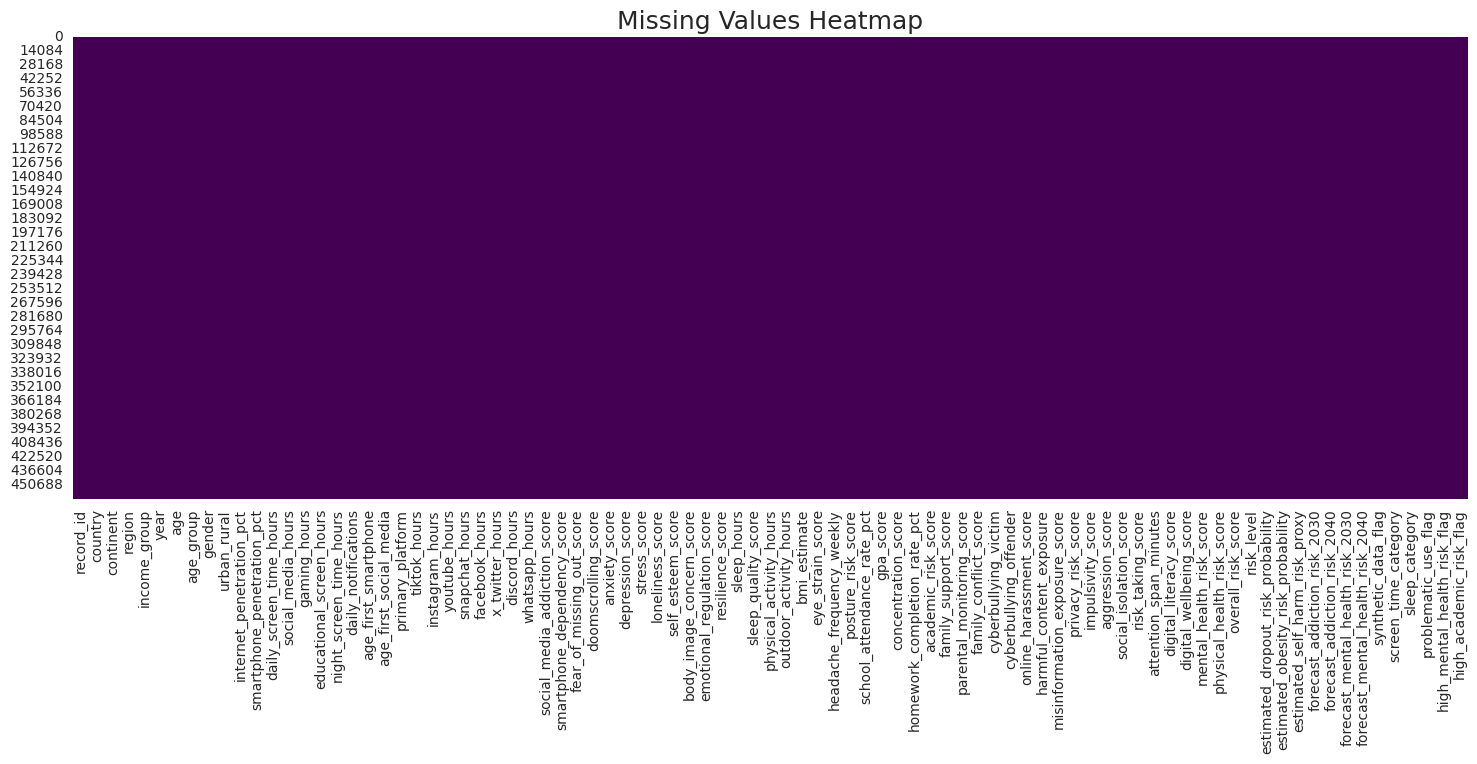

Numerical Columns : 76
Categorical Columns : 11


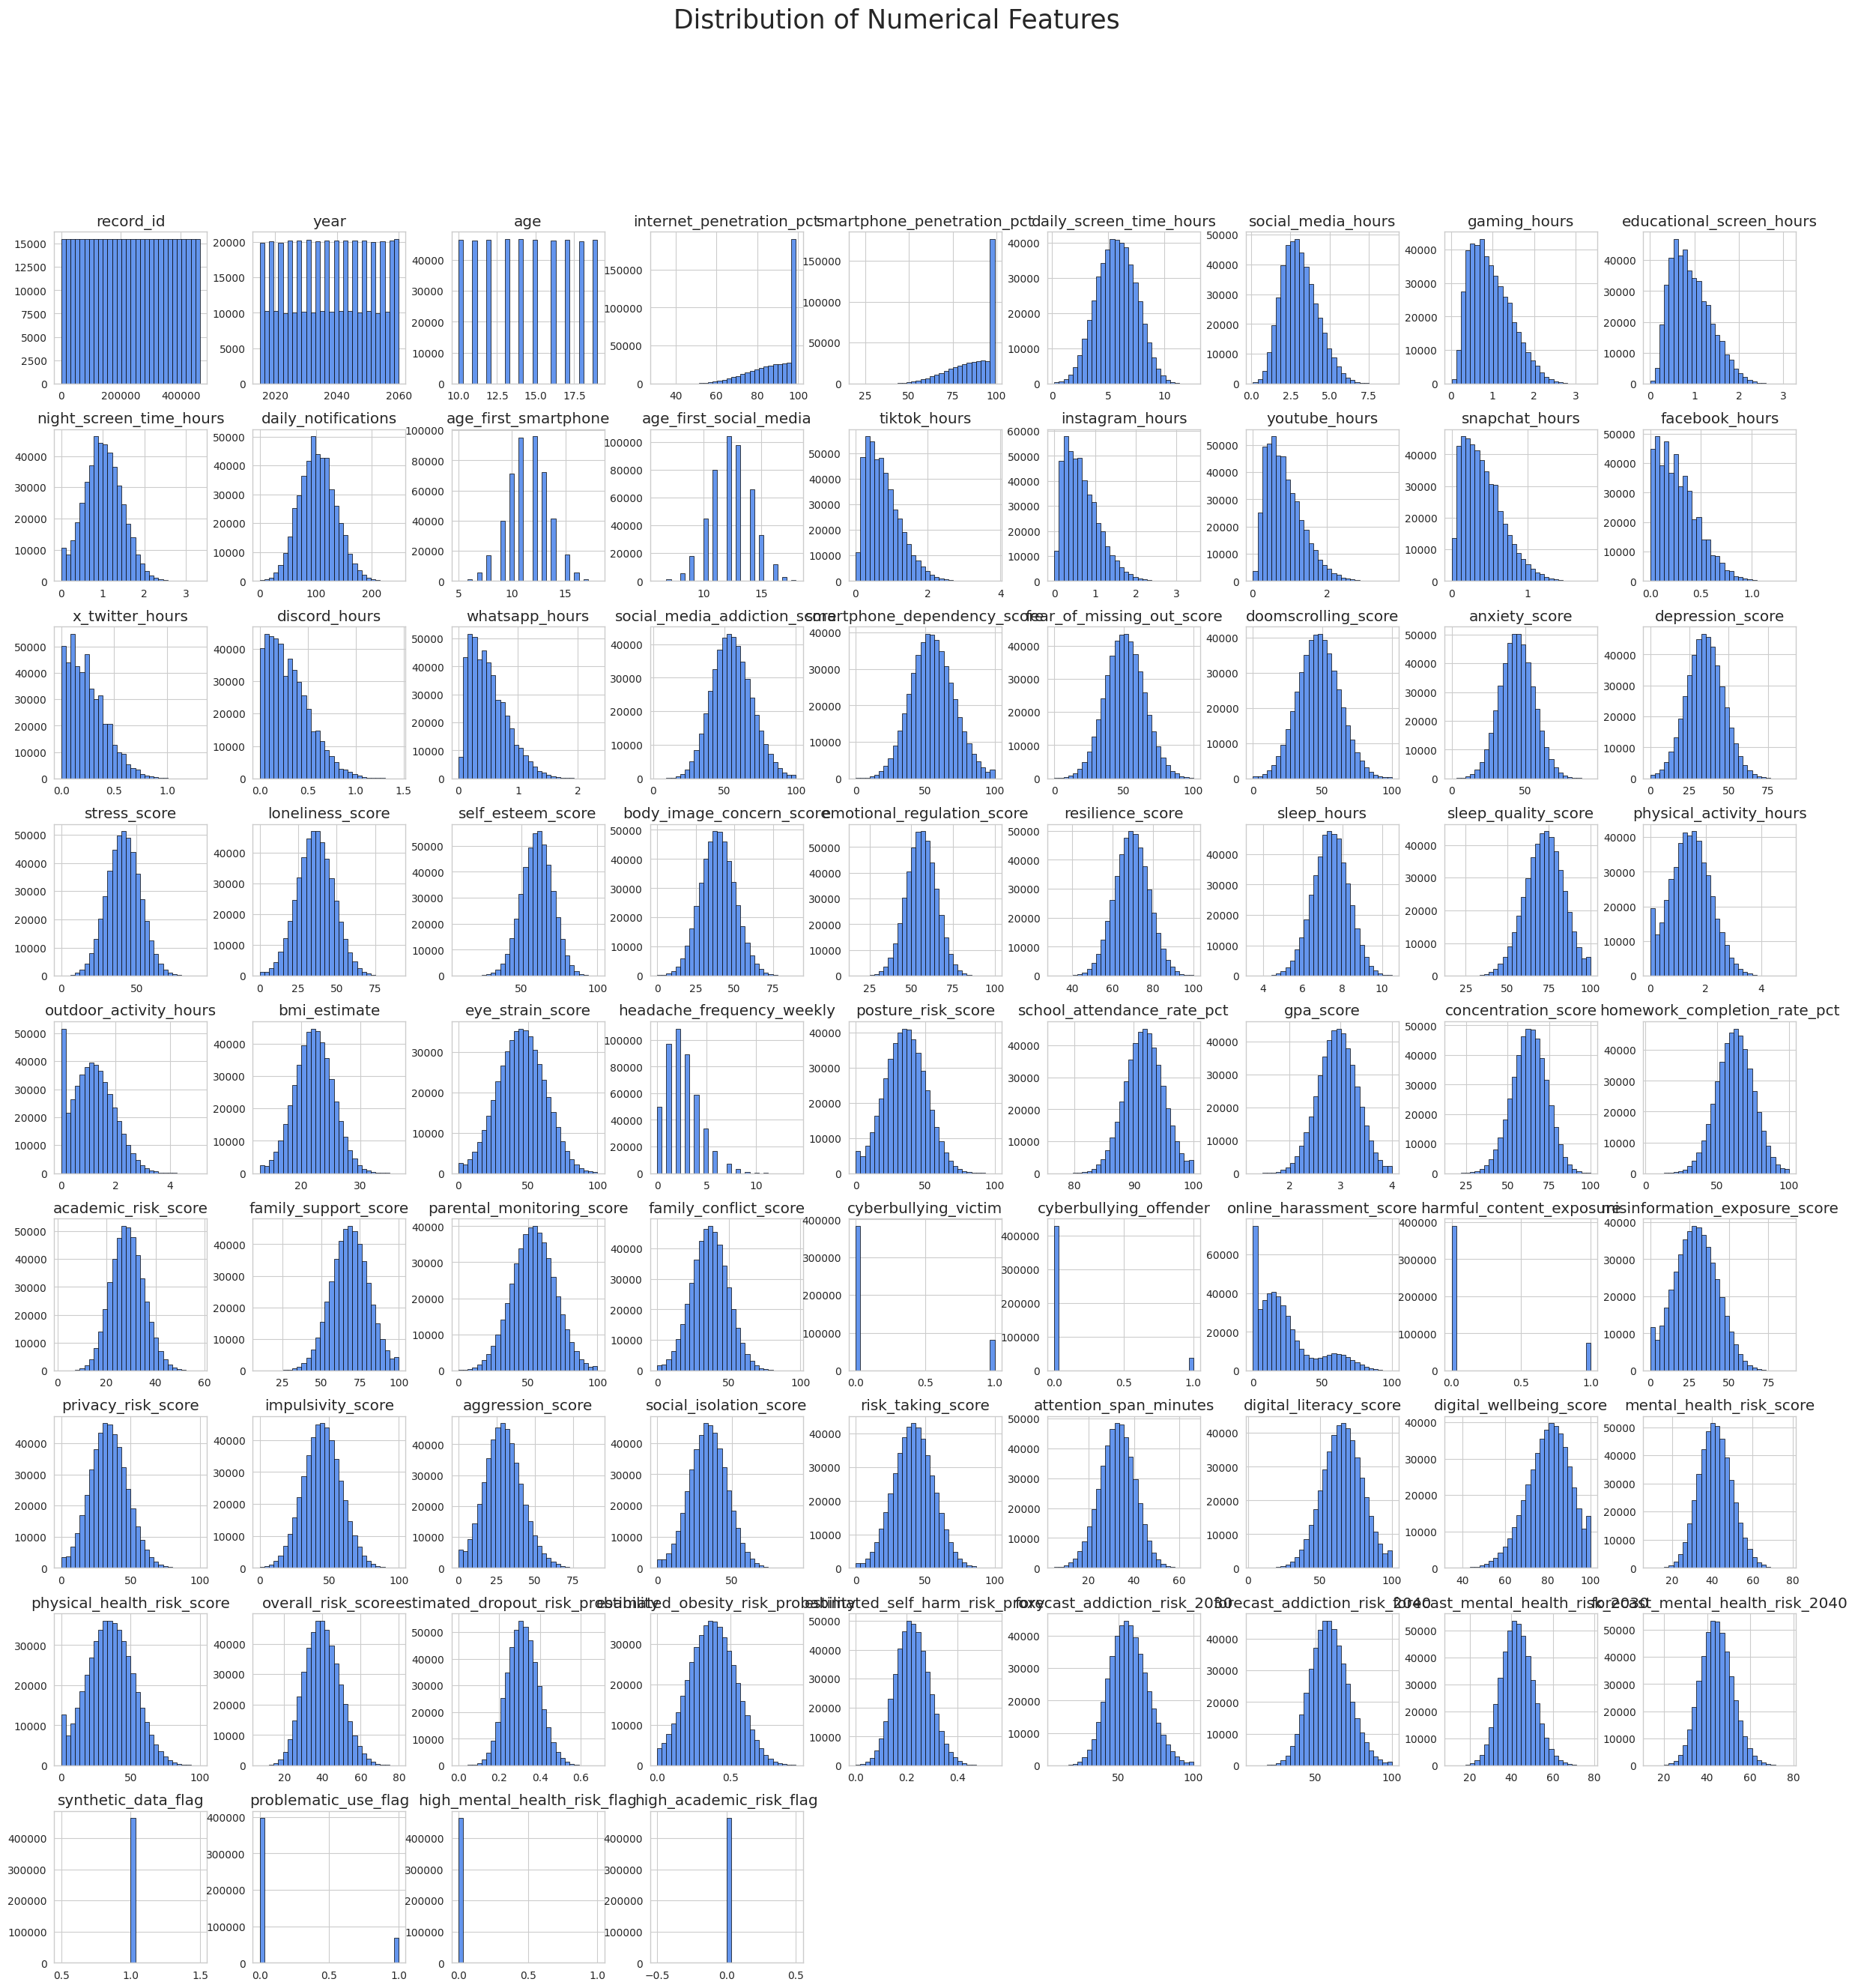

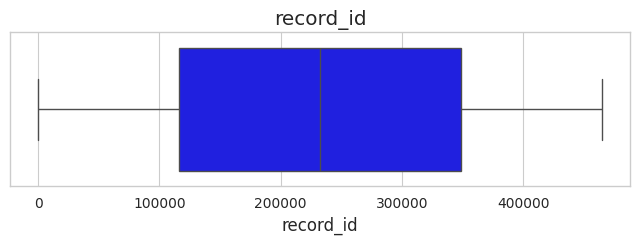

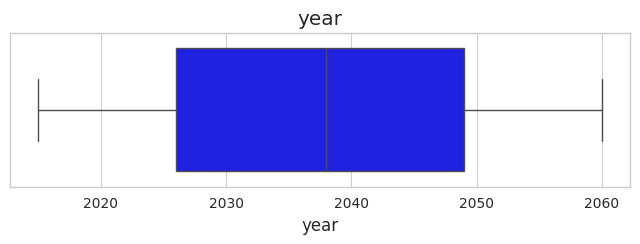

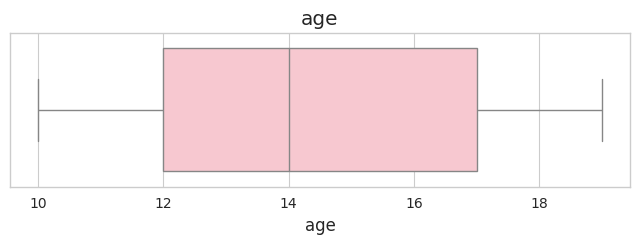

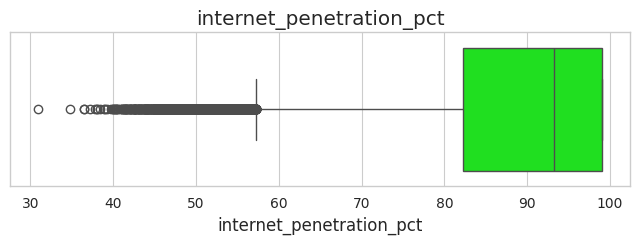

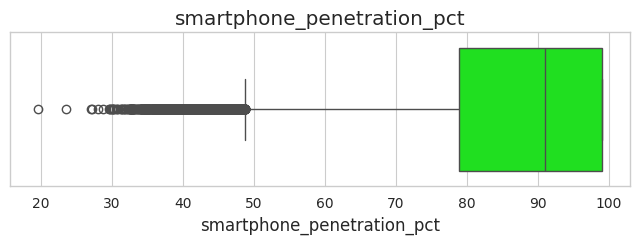

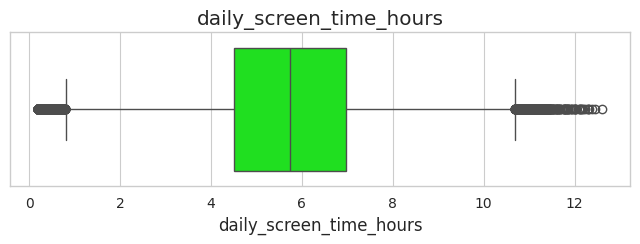

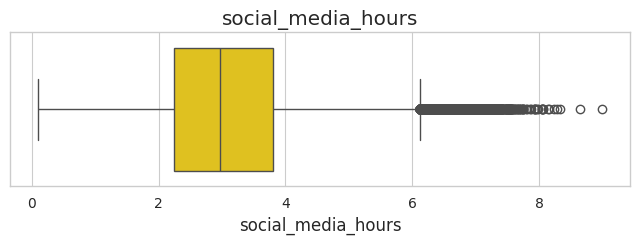

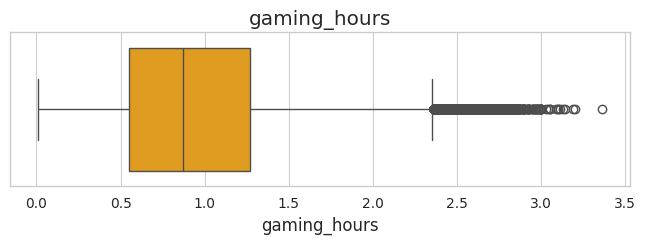

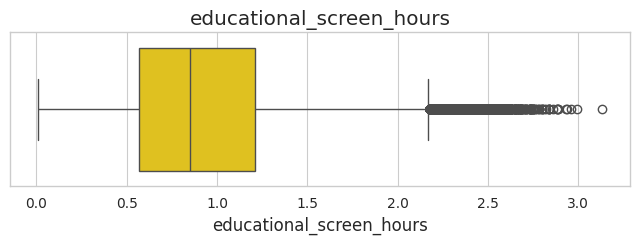

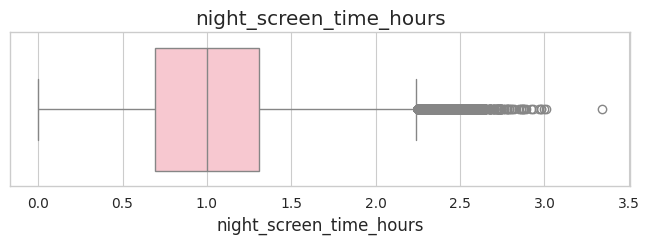

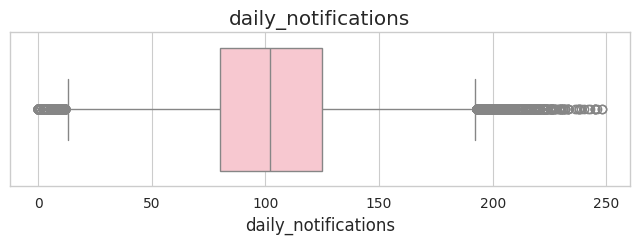

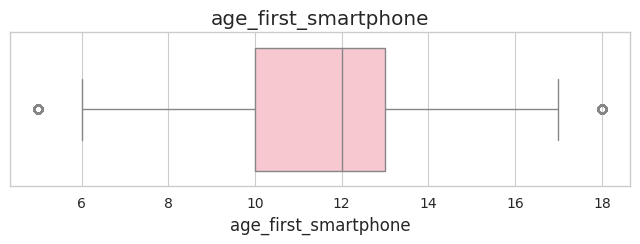

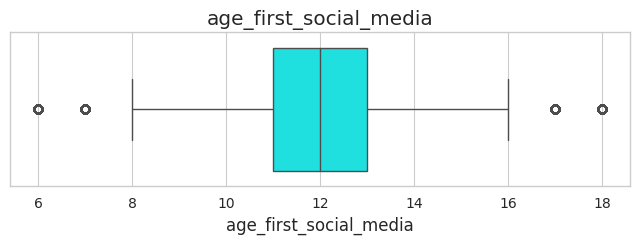

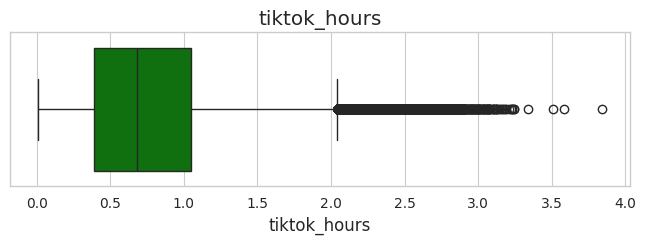

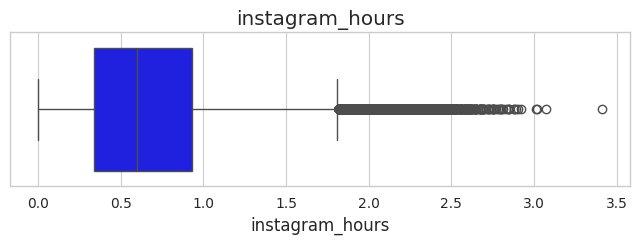

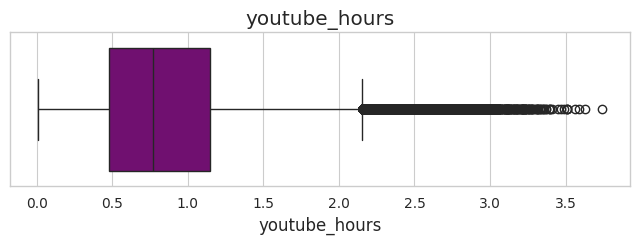

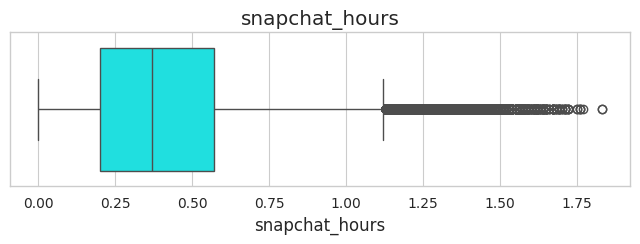

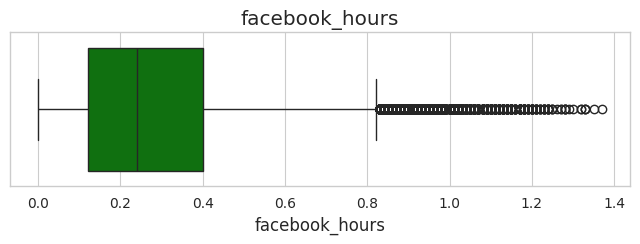

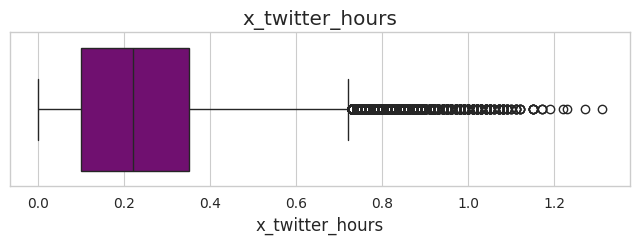

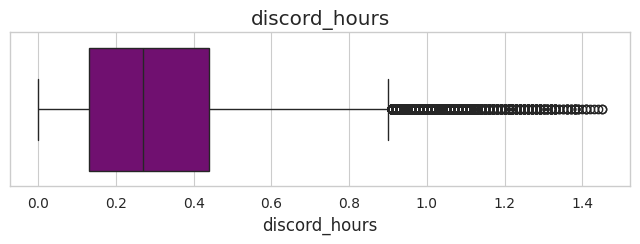

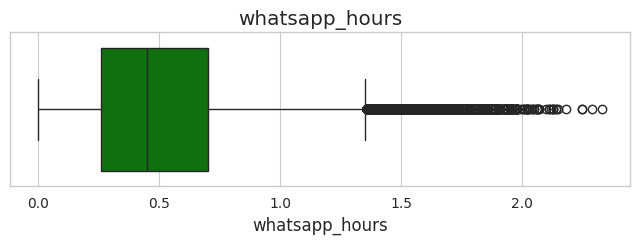

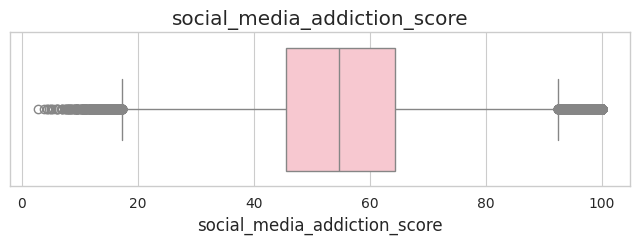

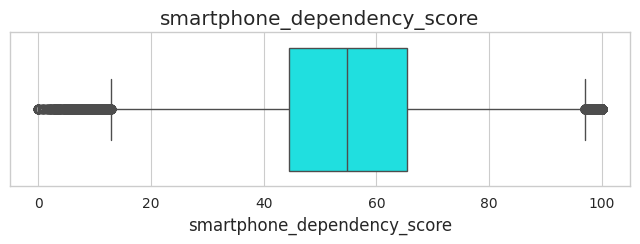

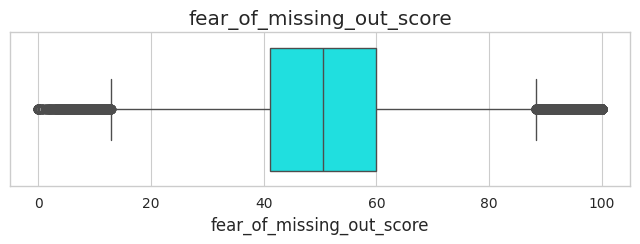

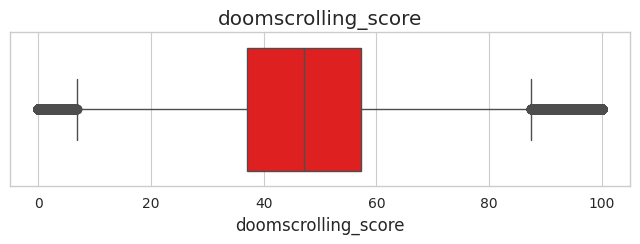

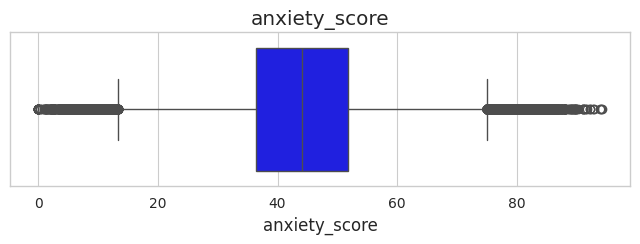

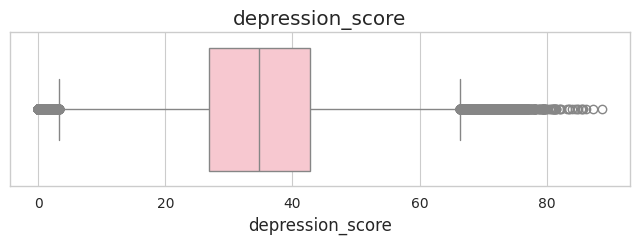

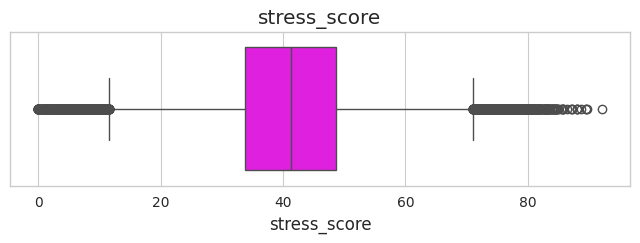

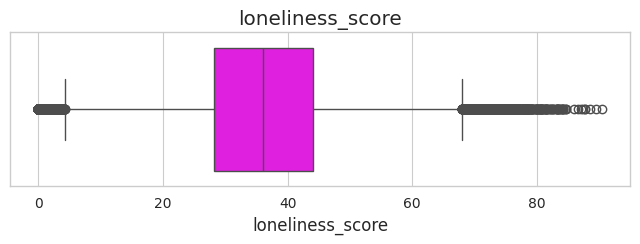

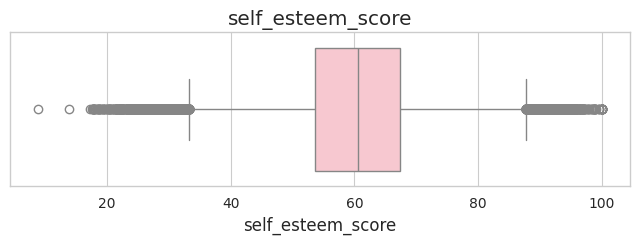

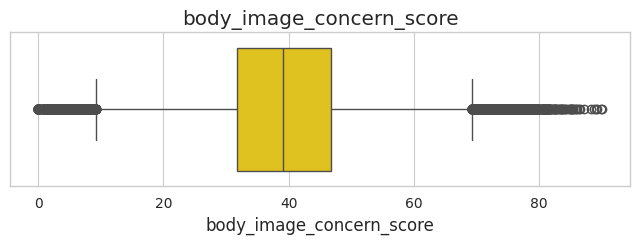

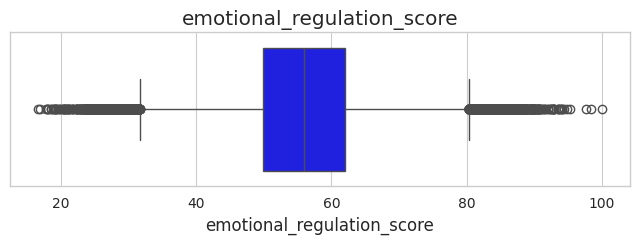

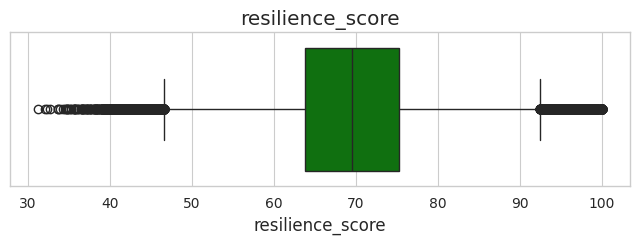

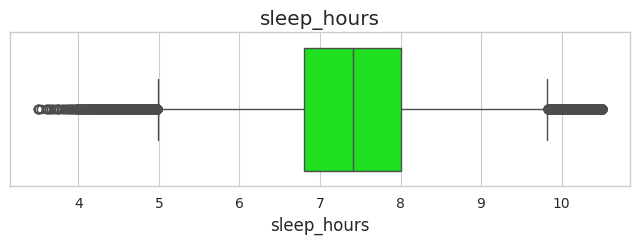

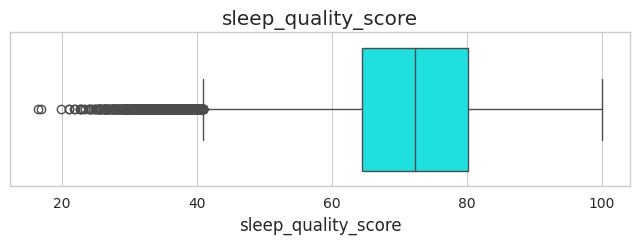

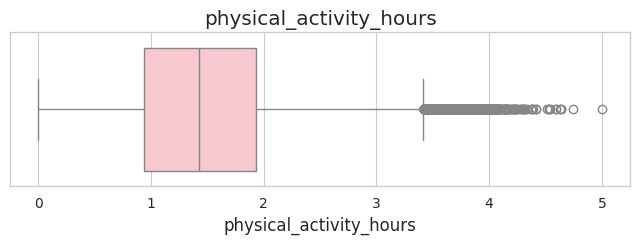

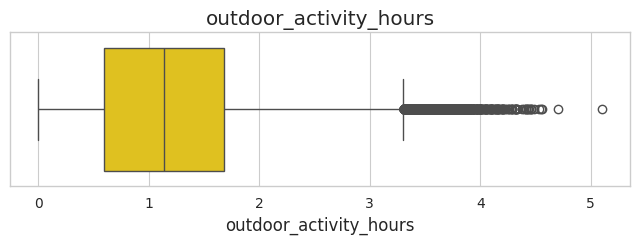

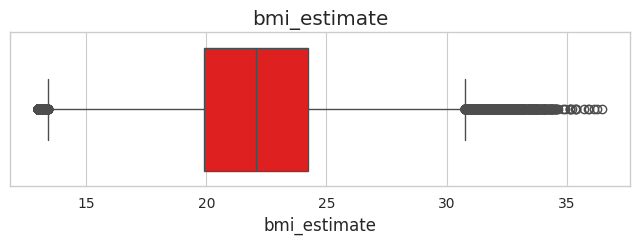

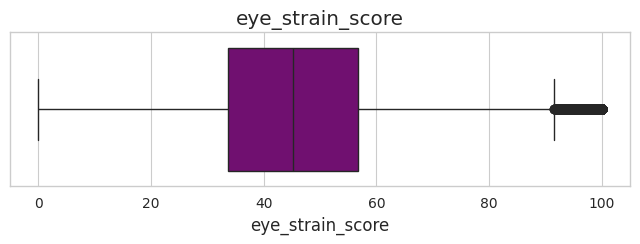

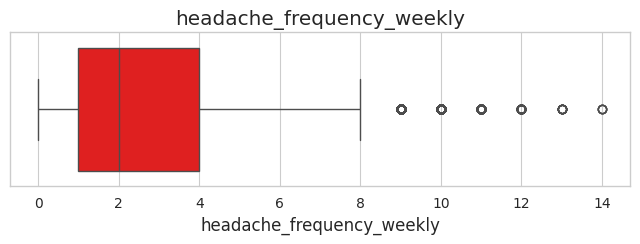

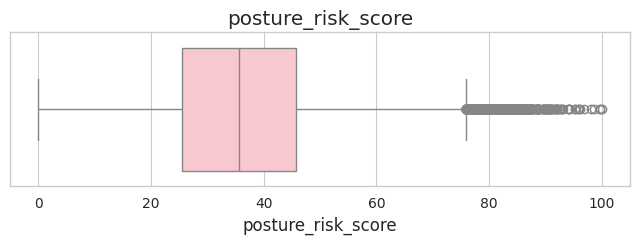

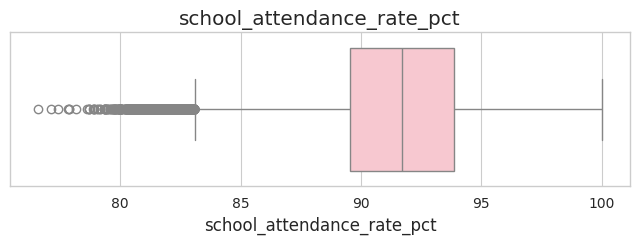

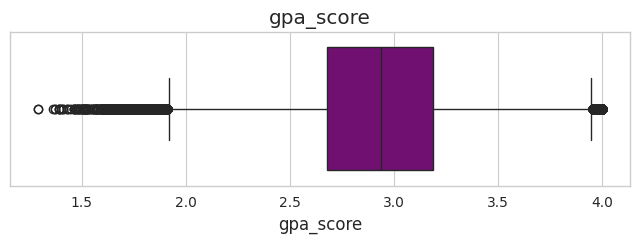

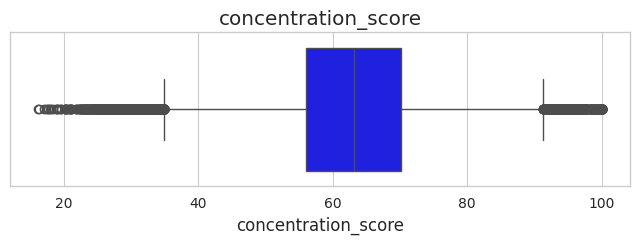

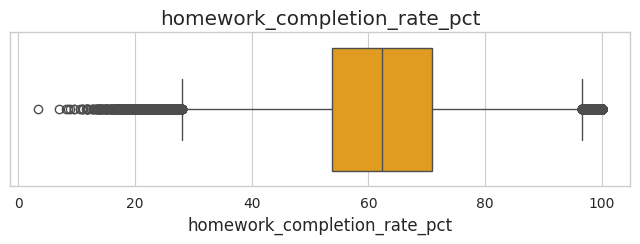

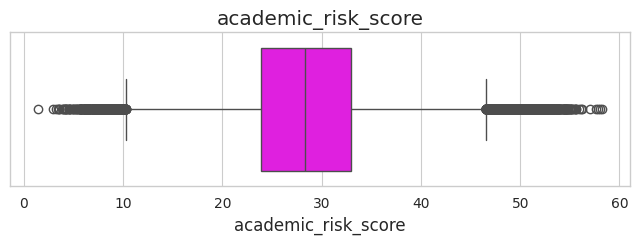

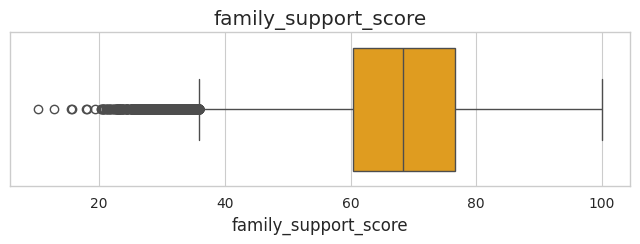

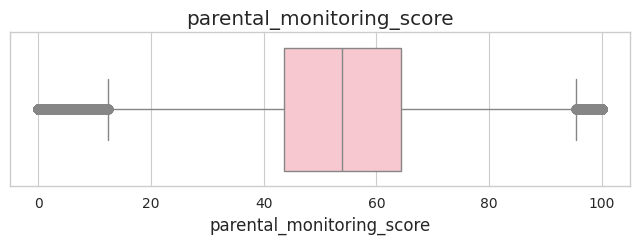

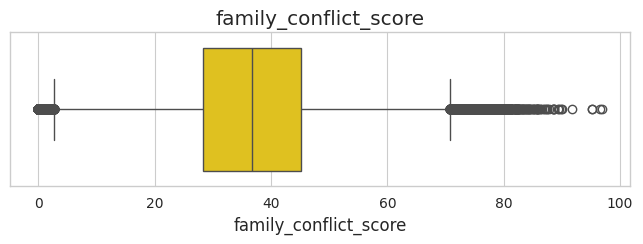

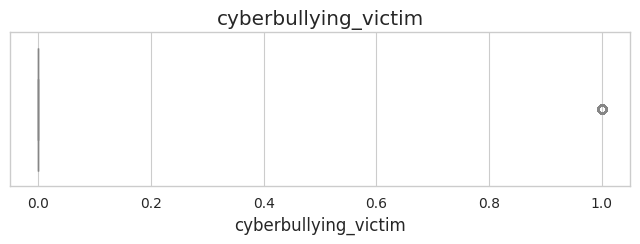

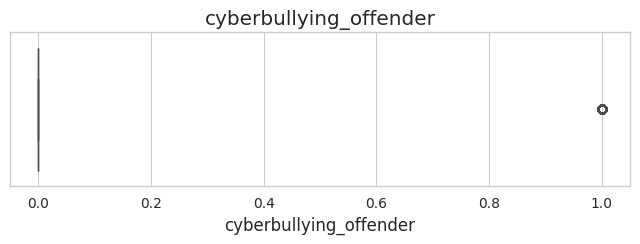

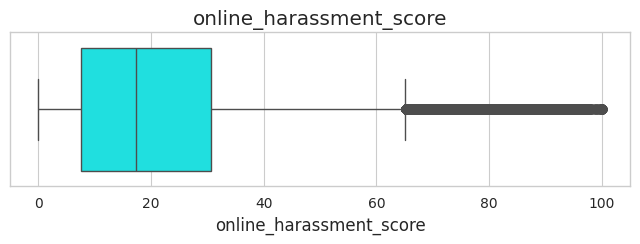

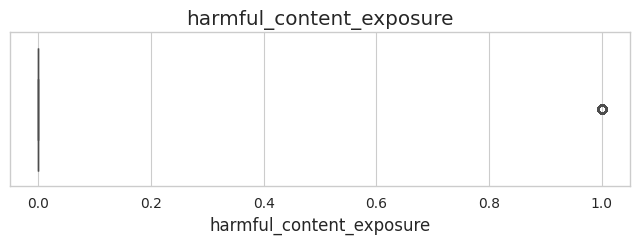

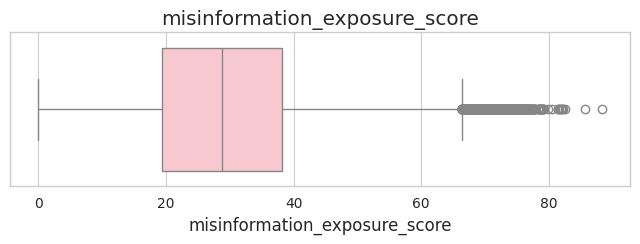

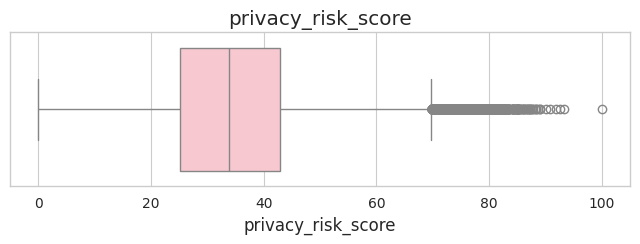

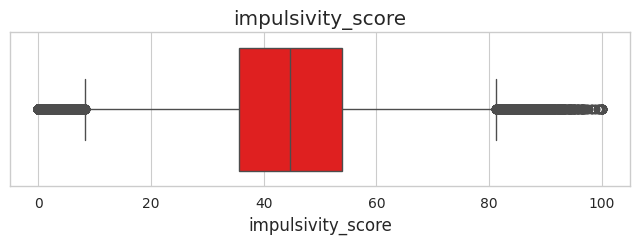

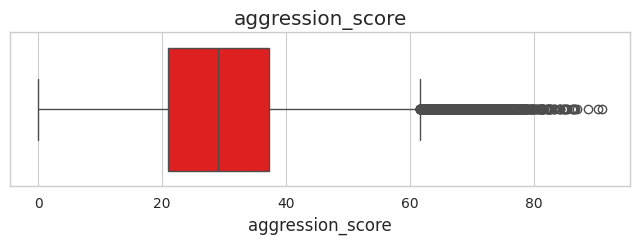

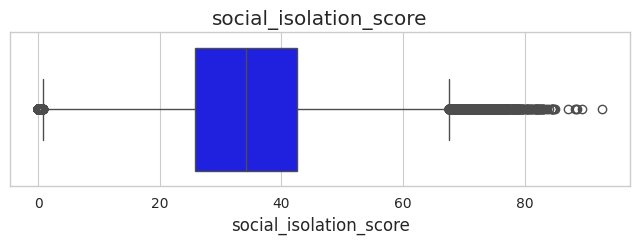

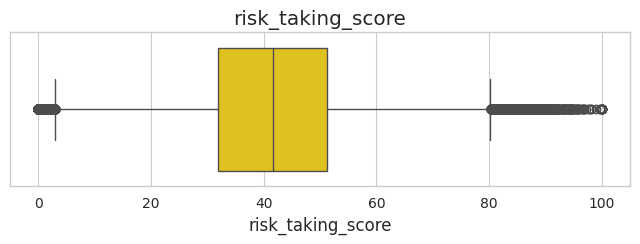

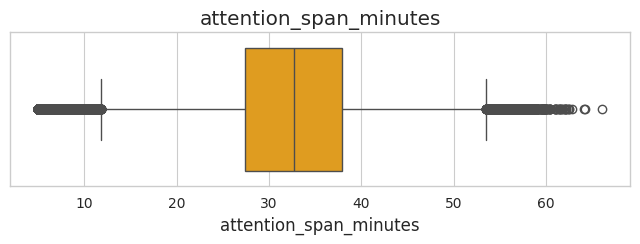

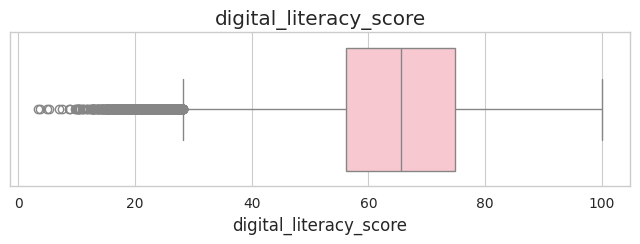

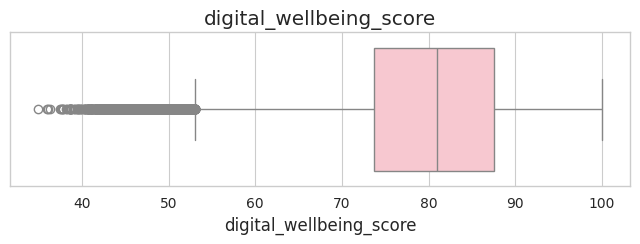

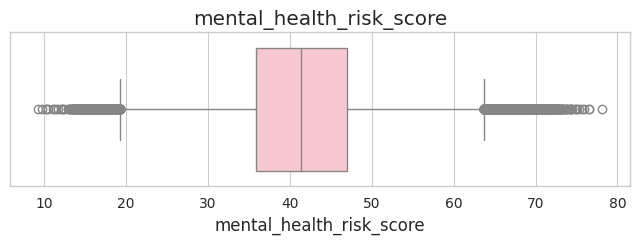

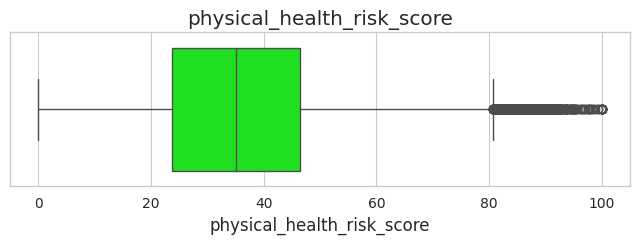

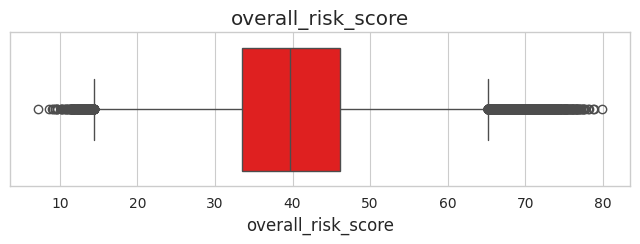

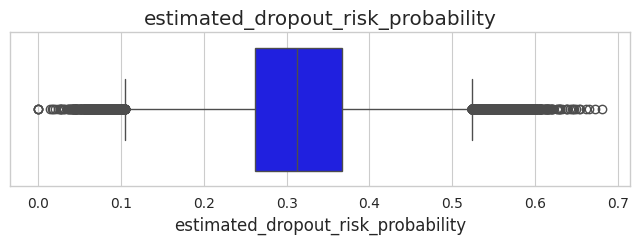

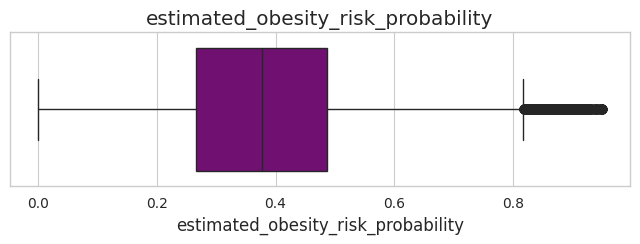

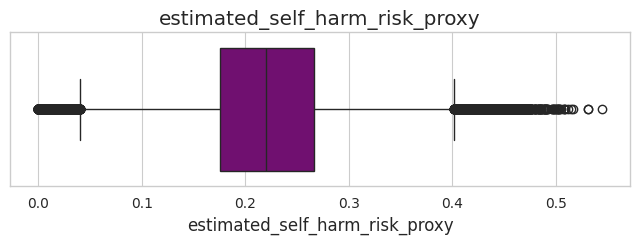

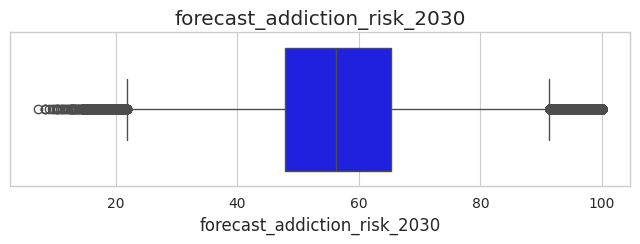

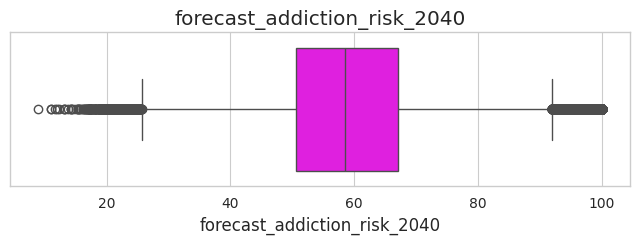

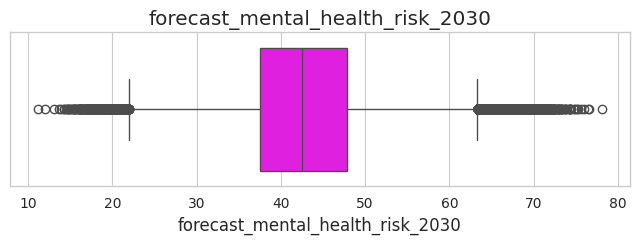

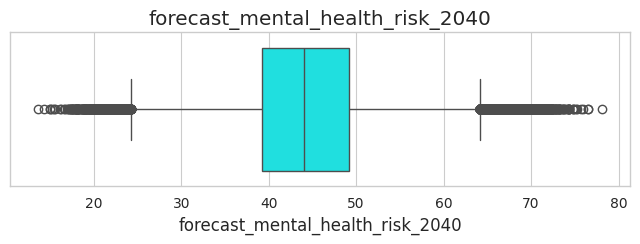

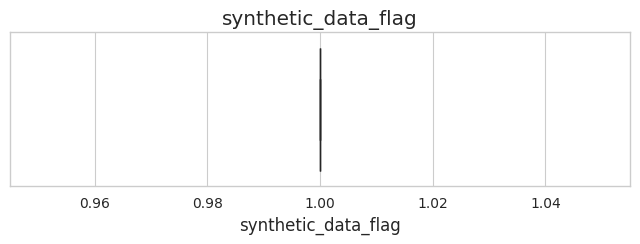

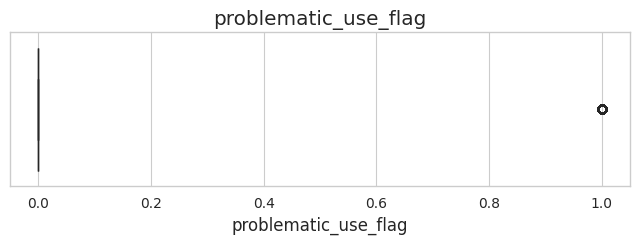

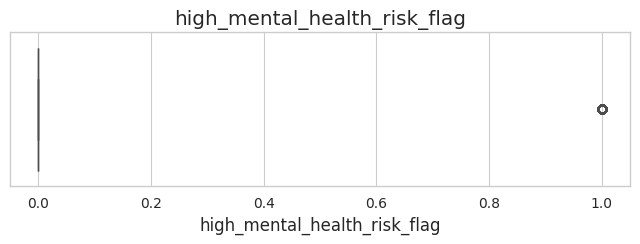

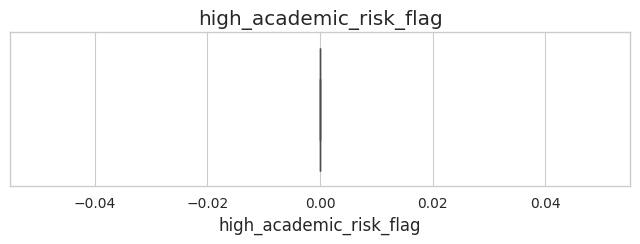

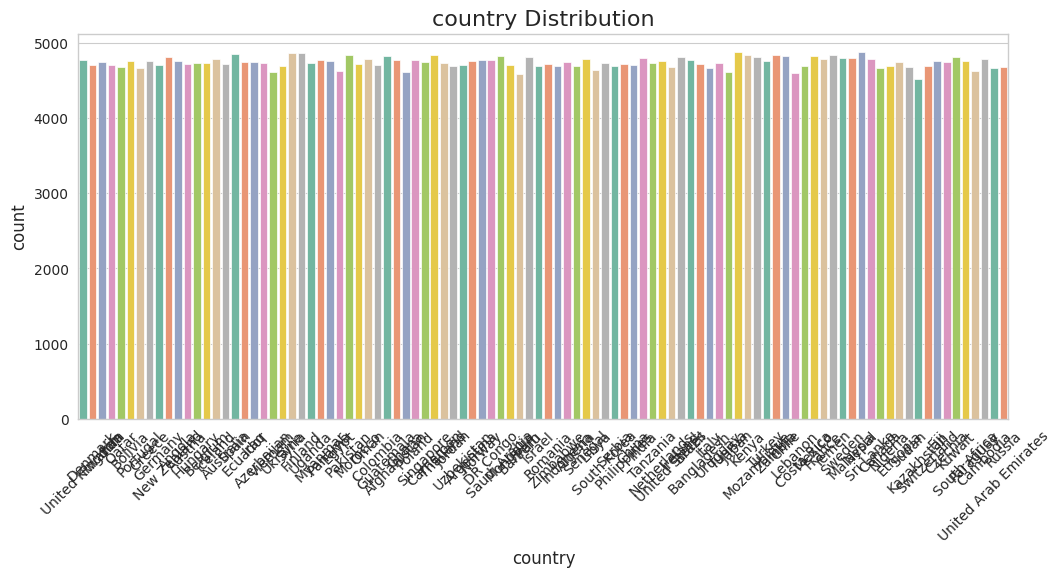

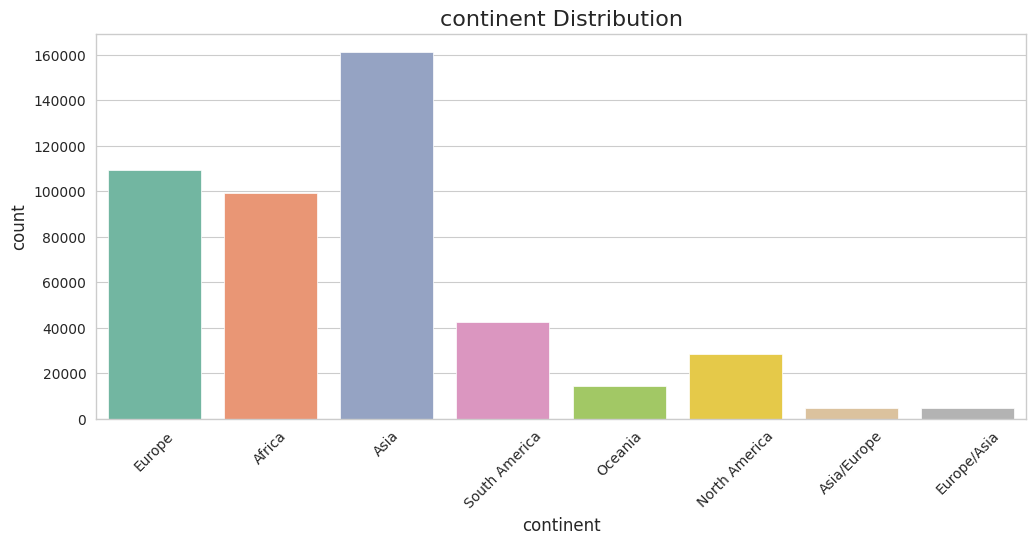

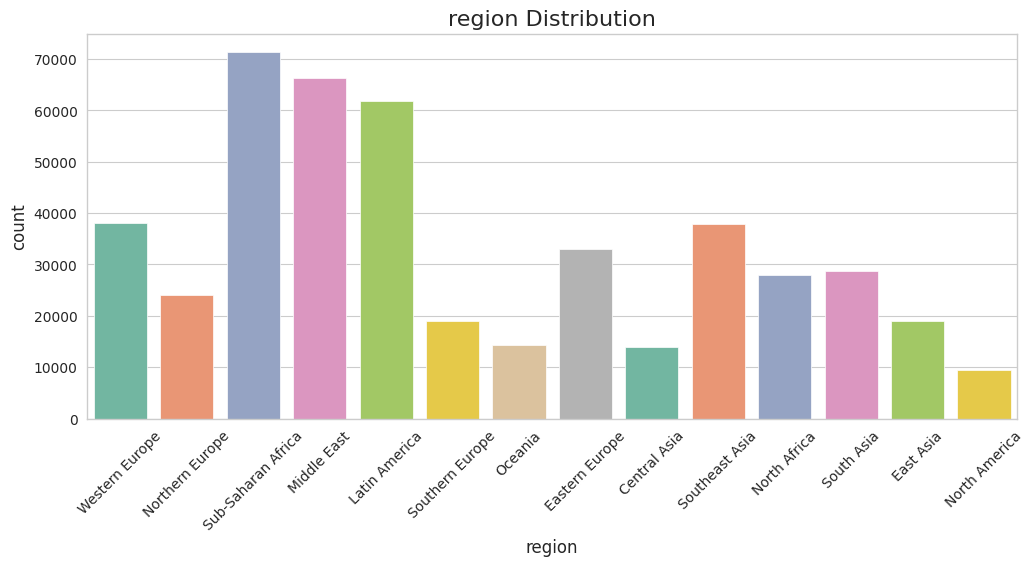

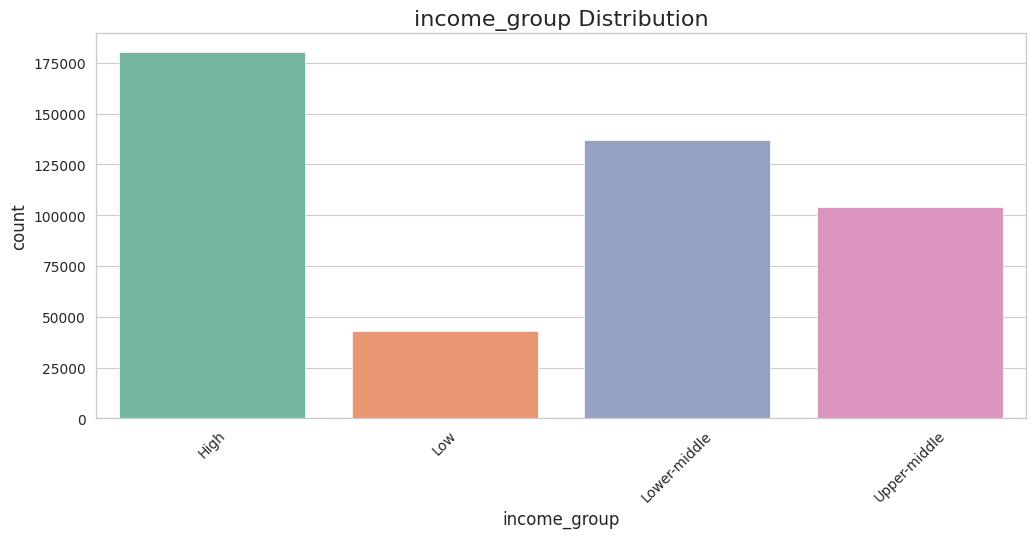

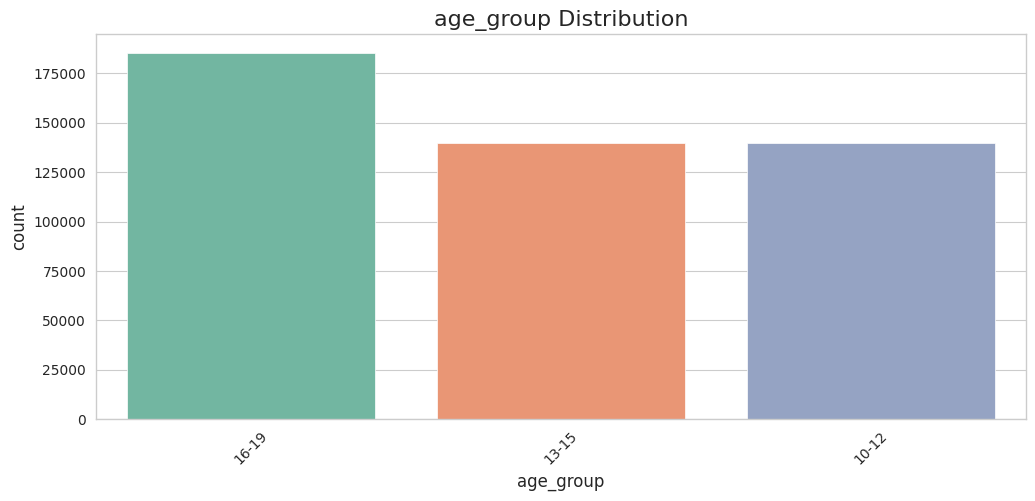

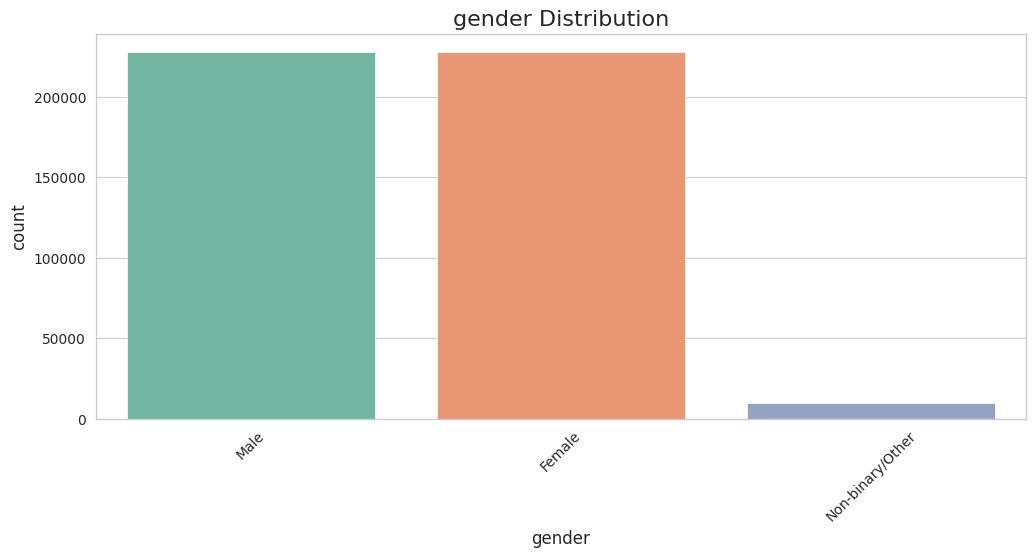

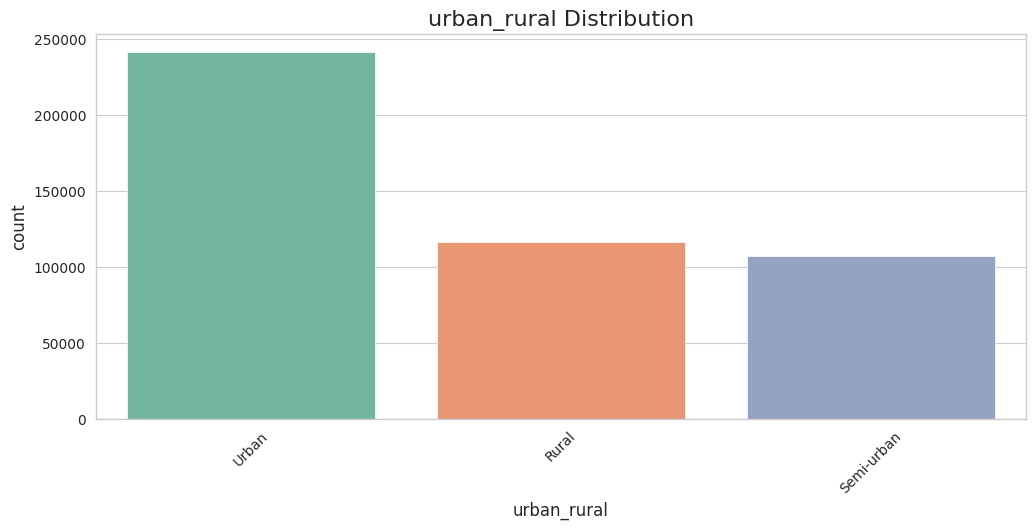

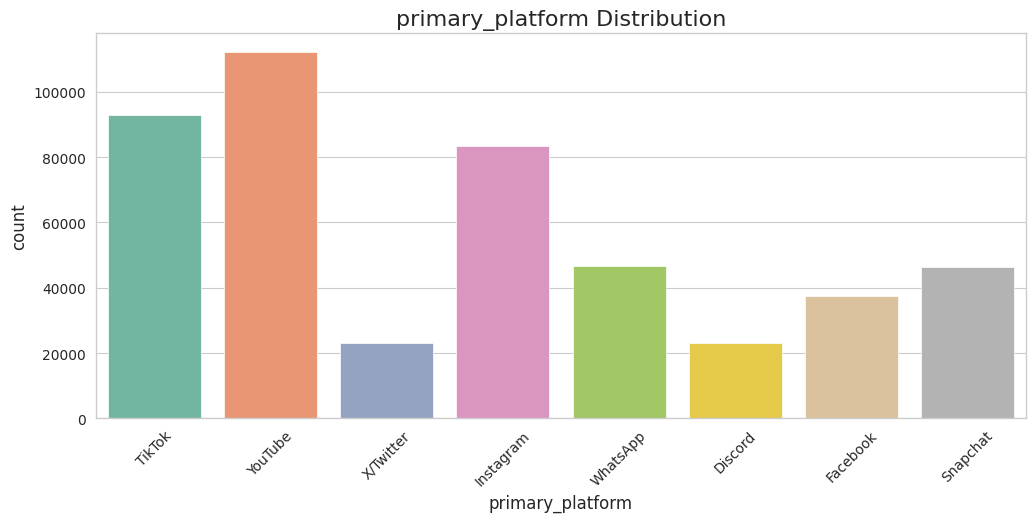

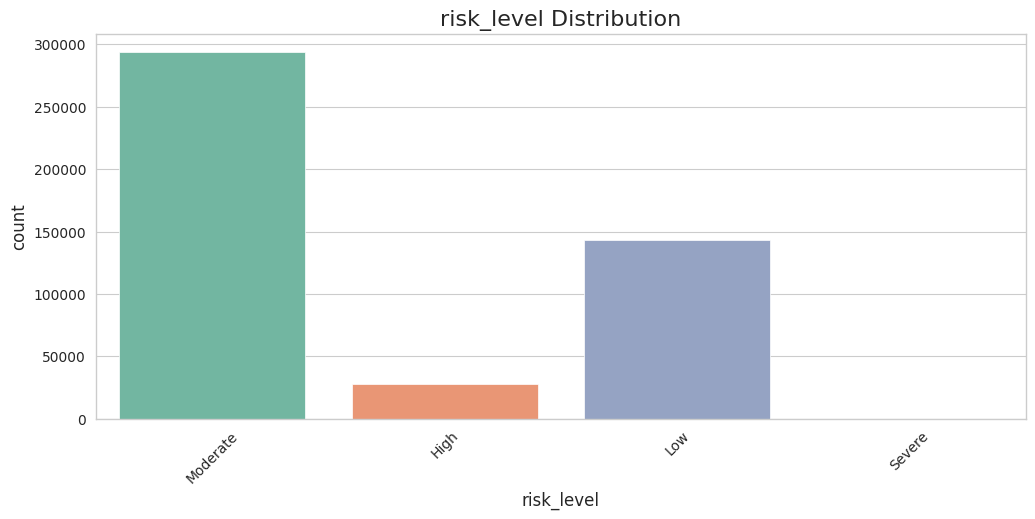

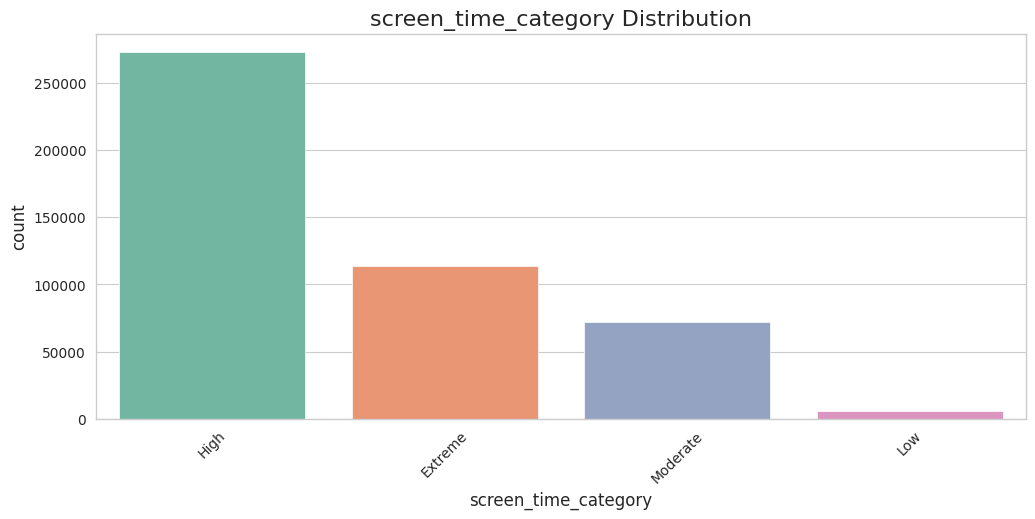

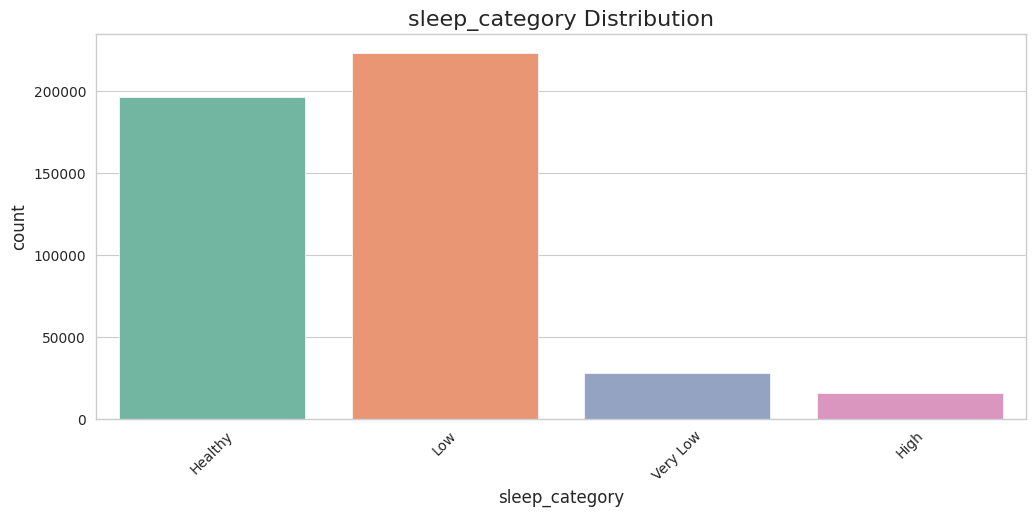

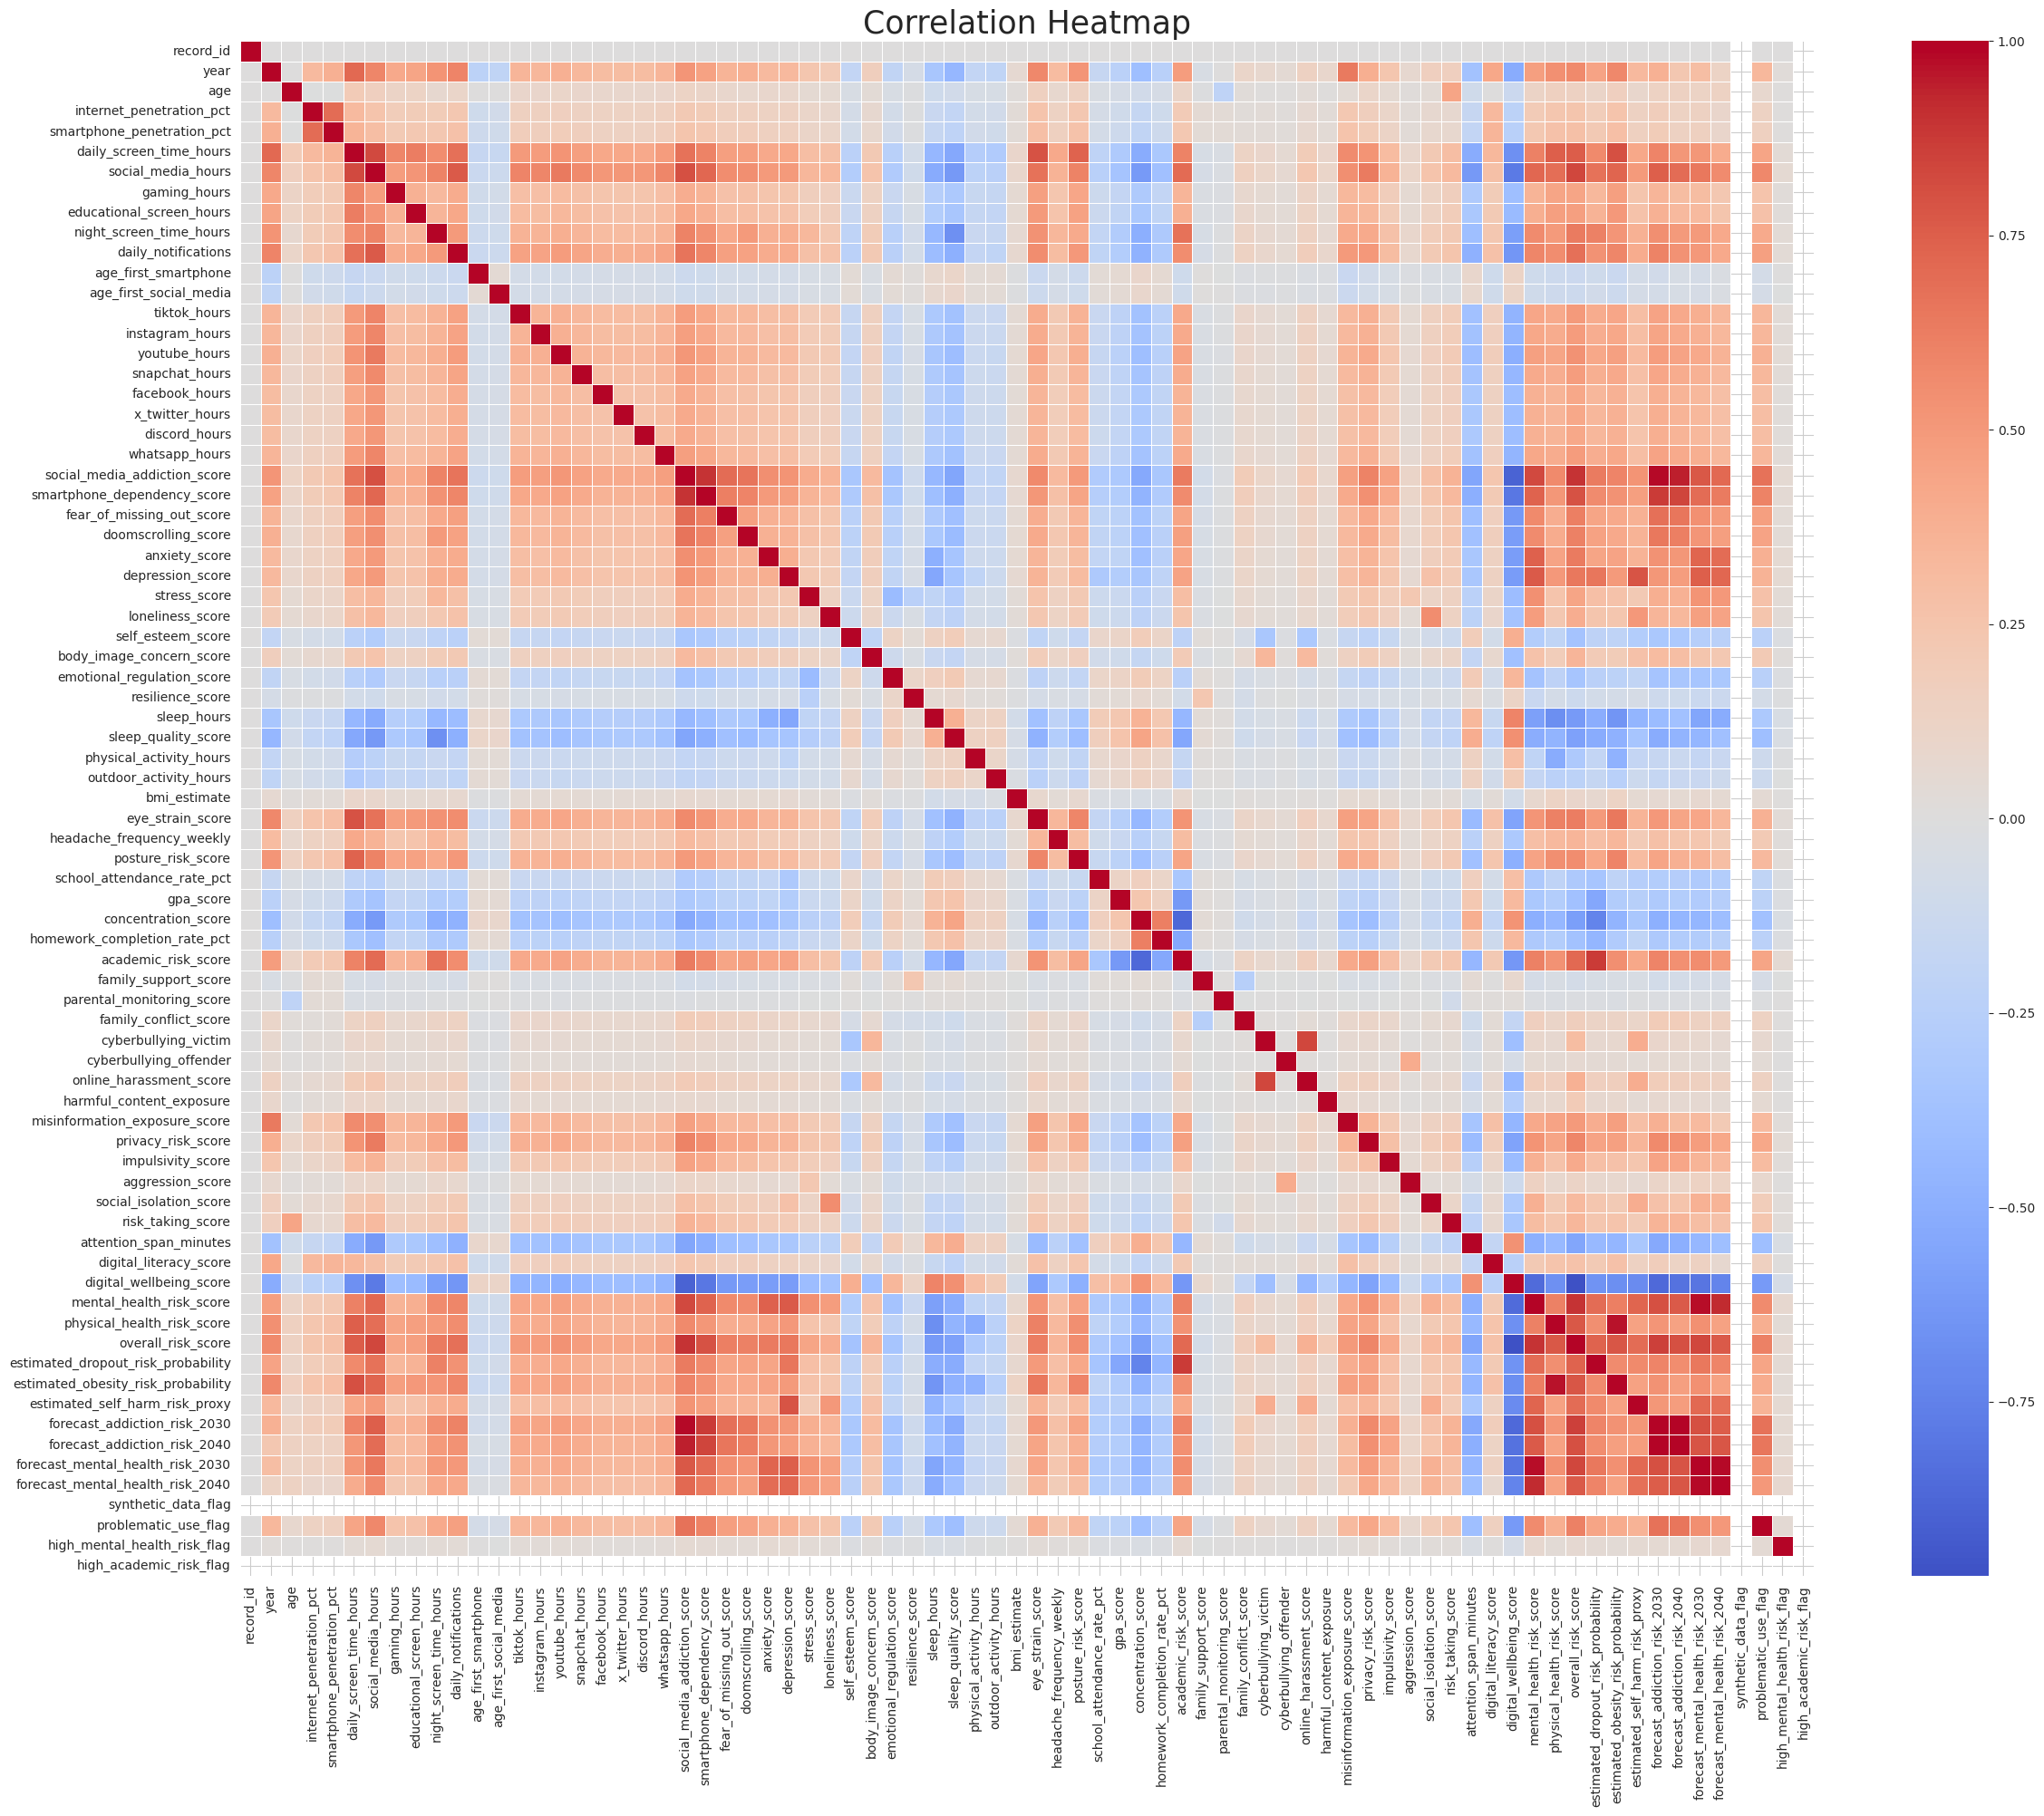

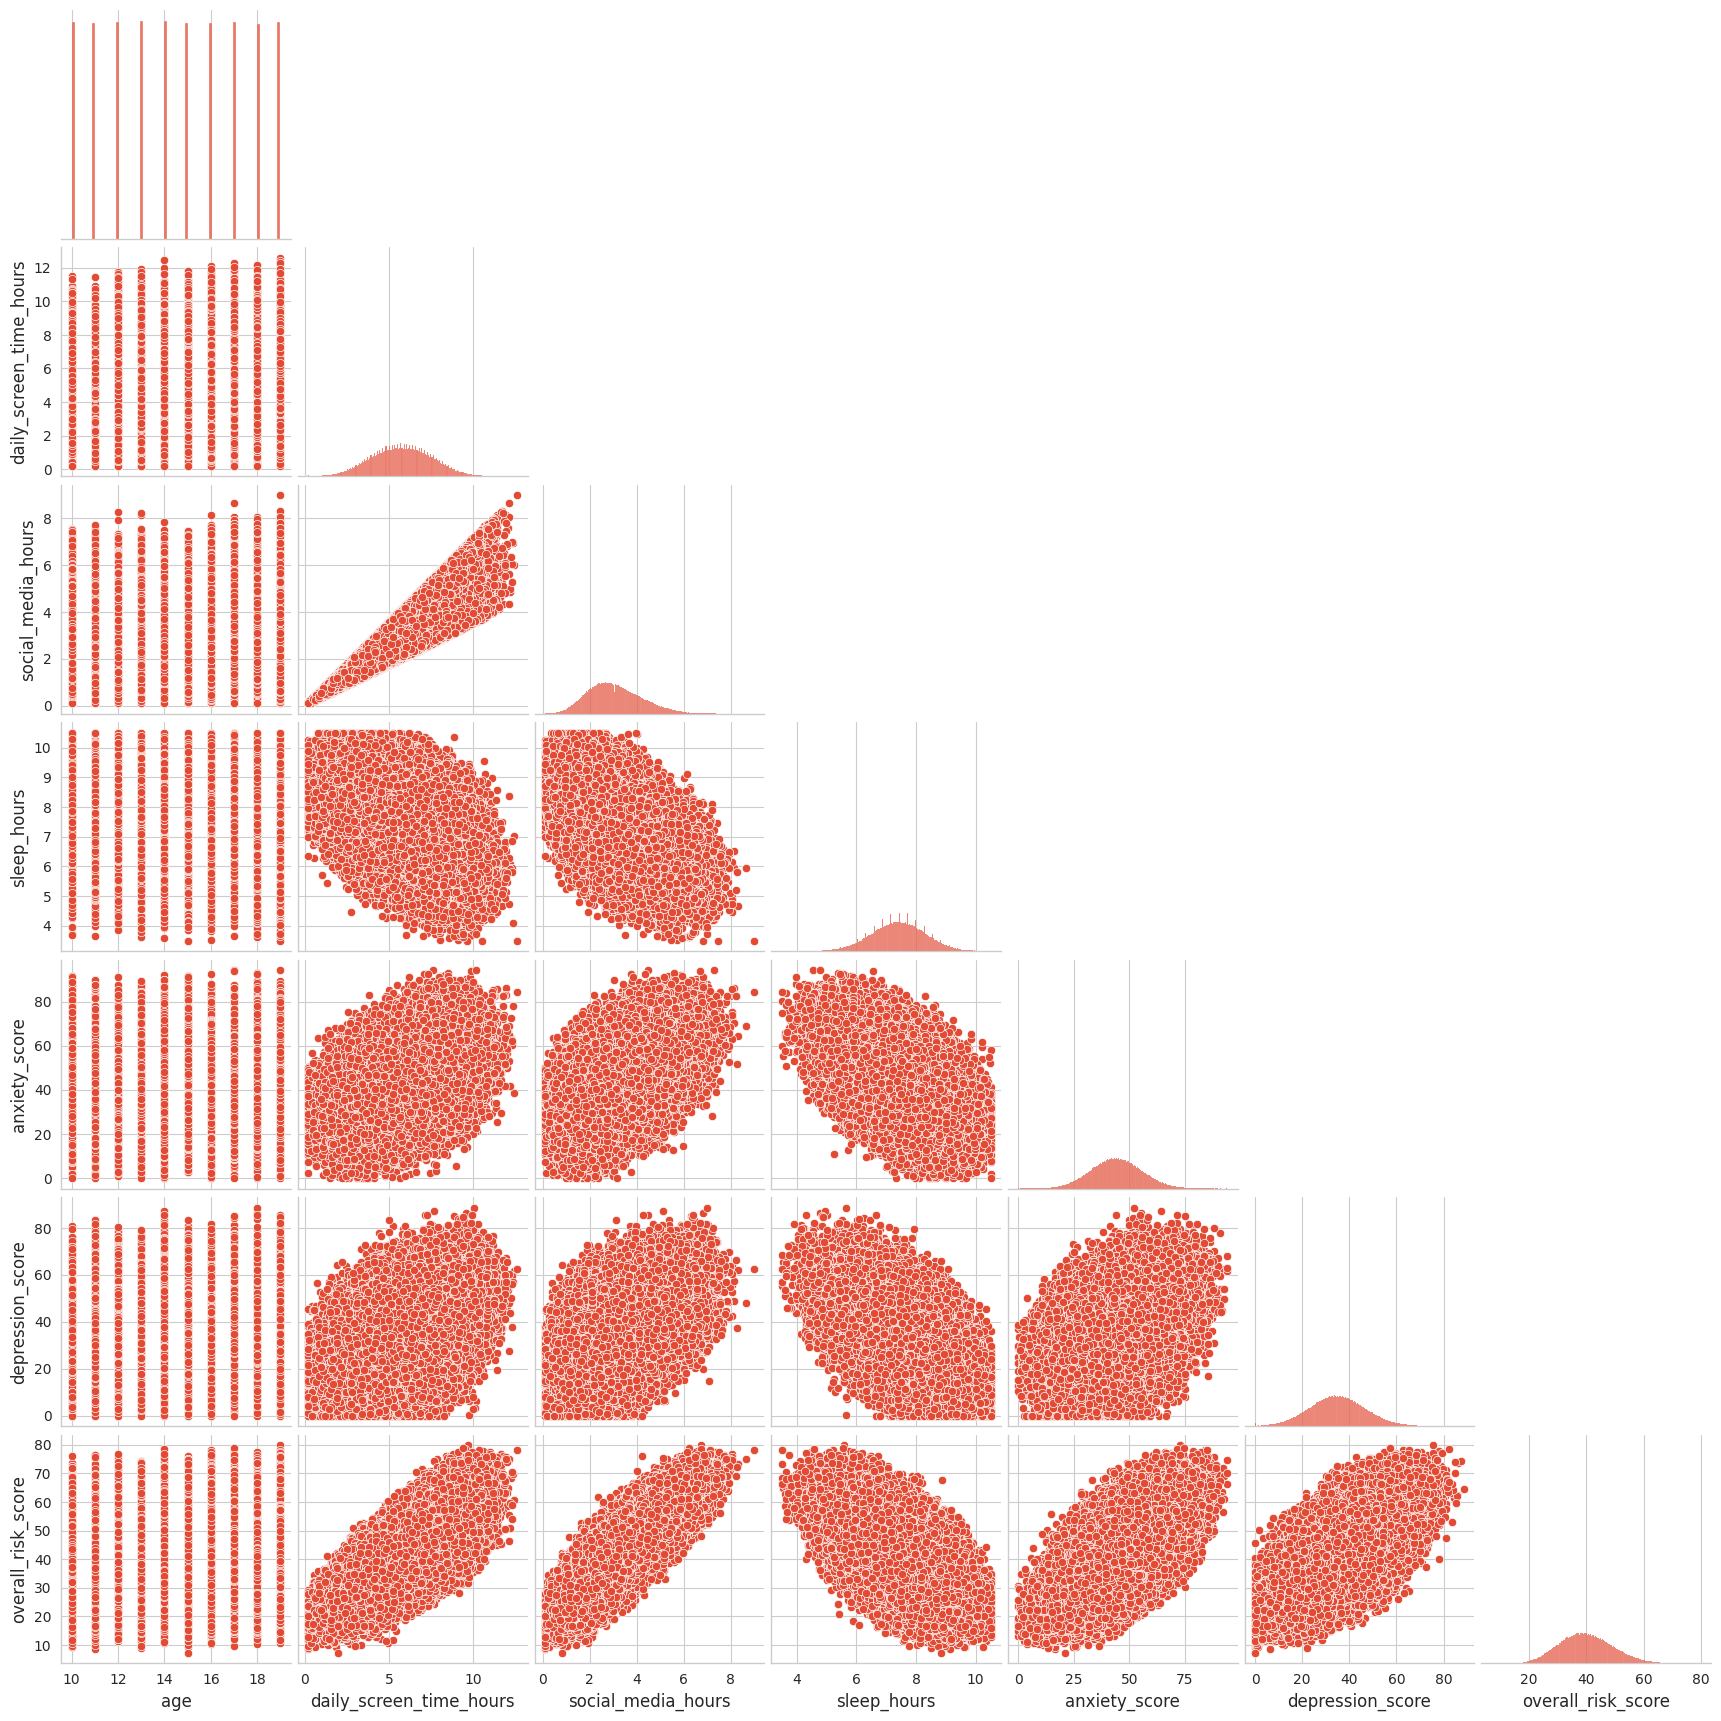

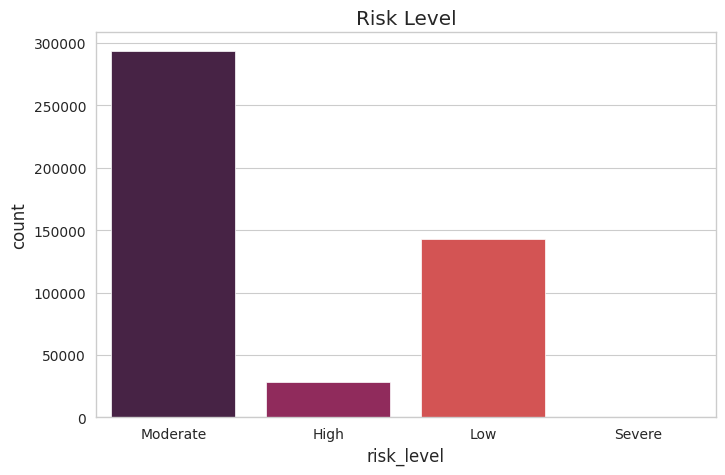

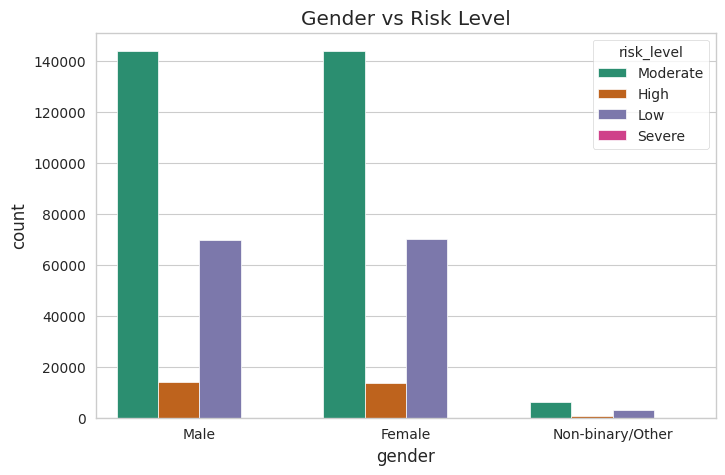

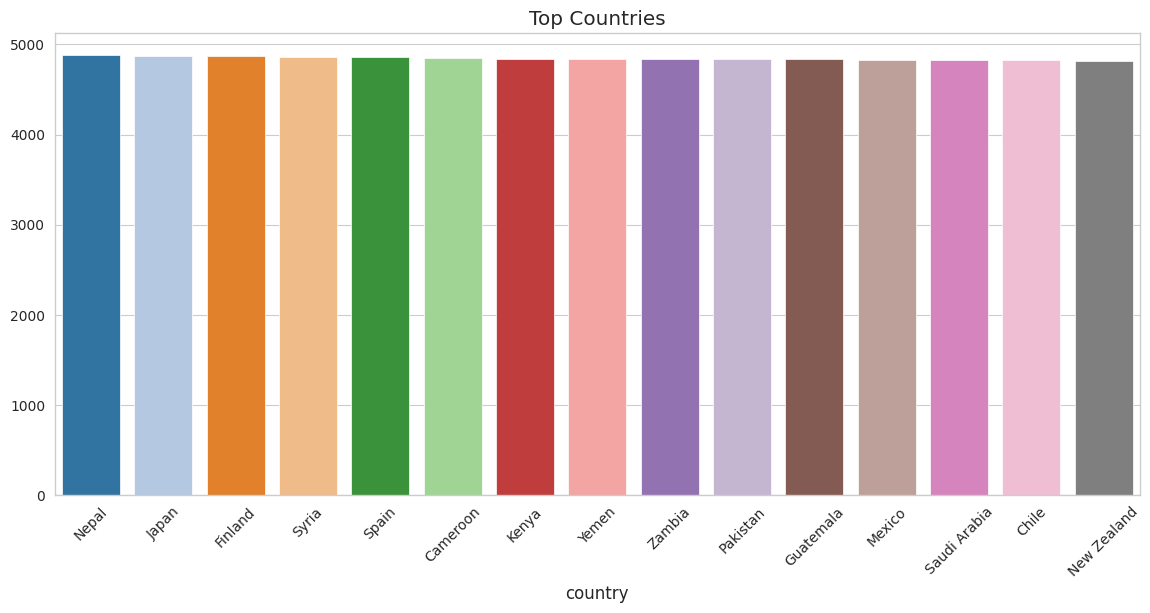

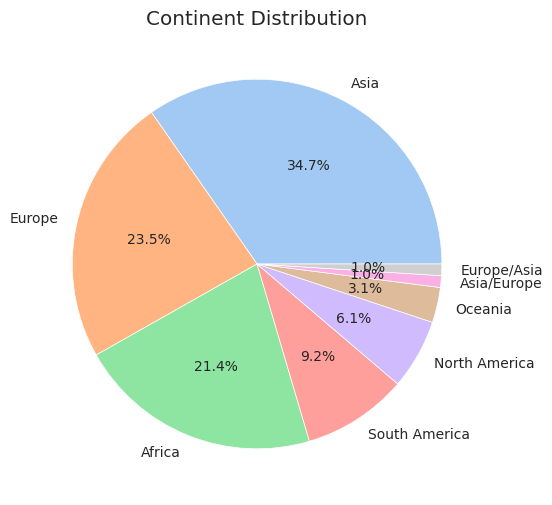

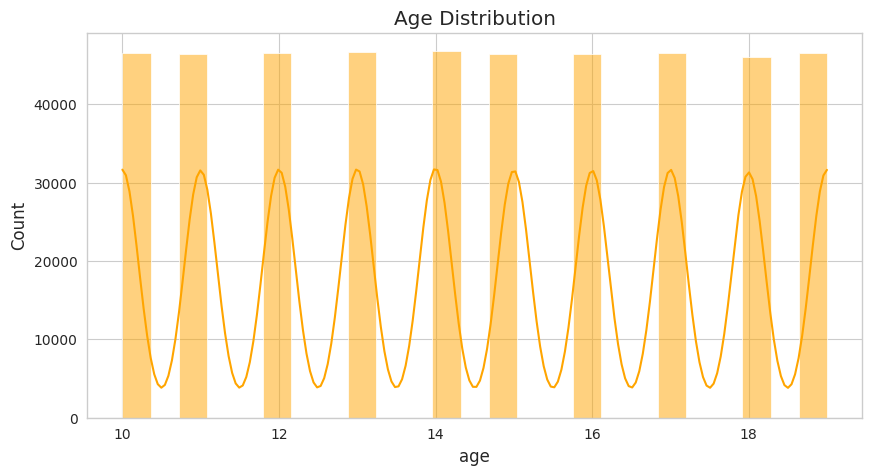

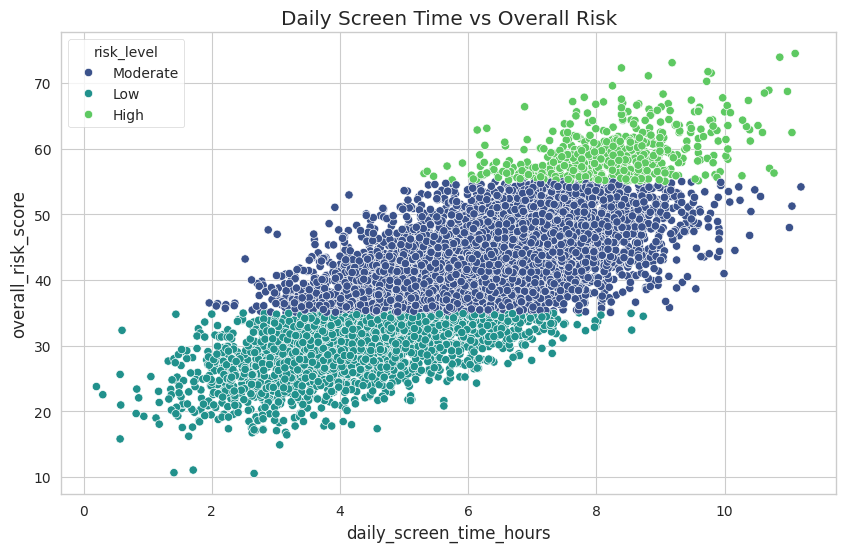

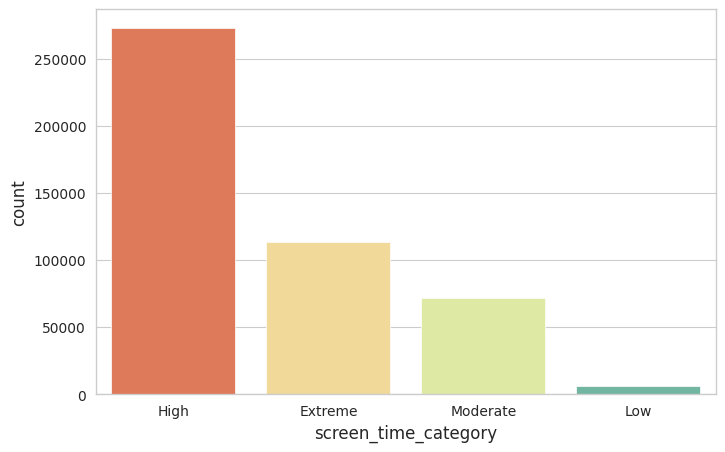

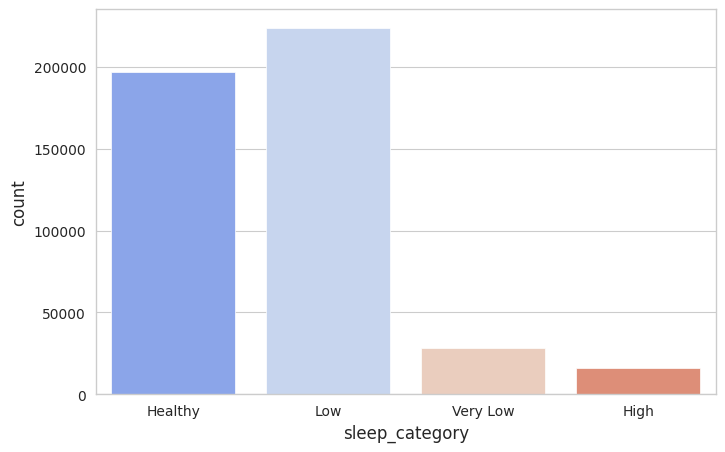

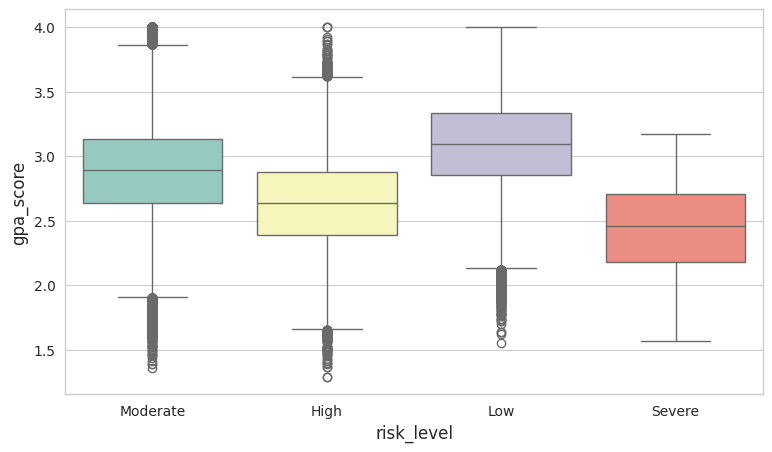

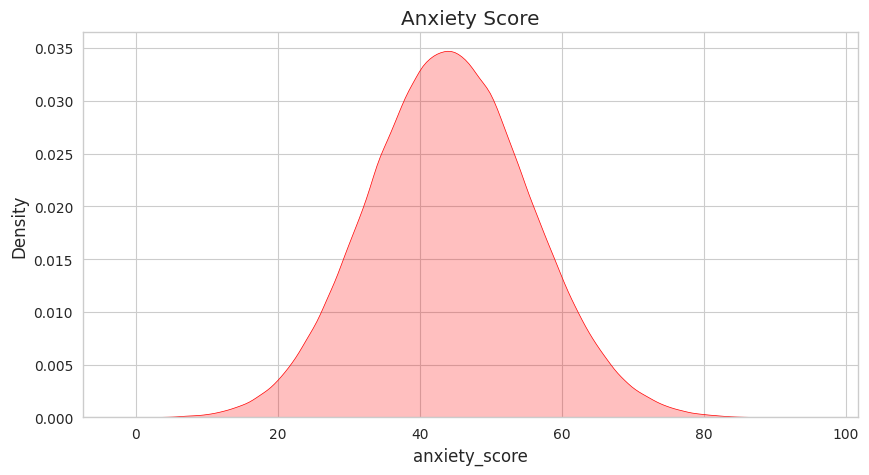

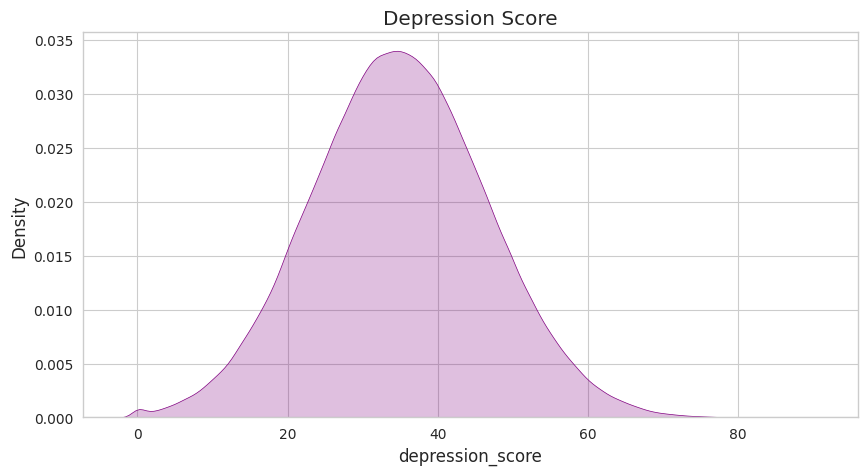

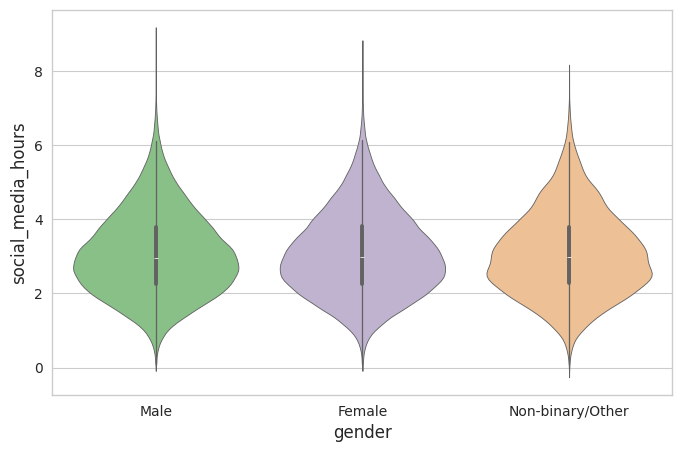

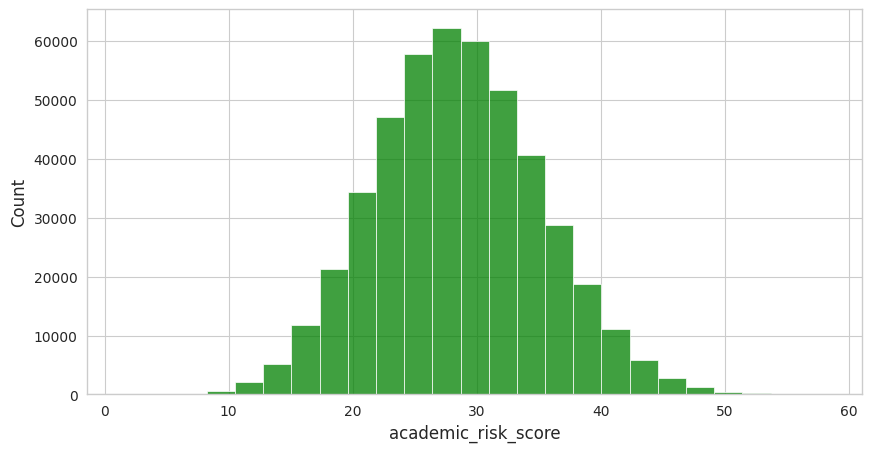

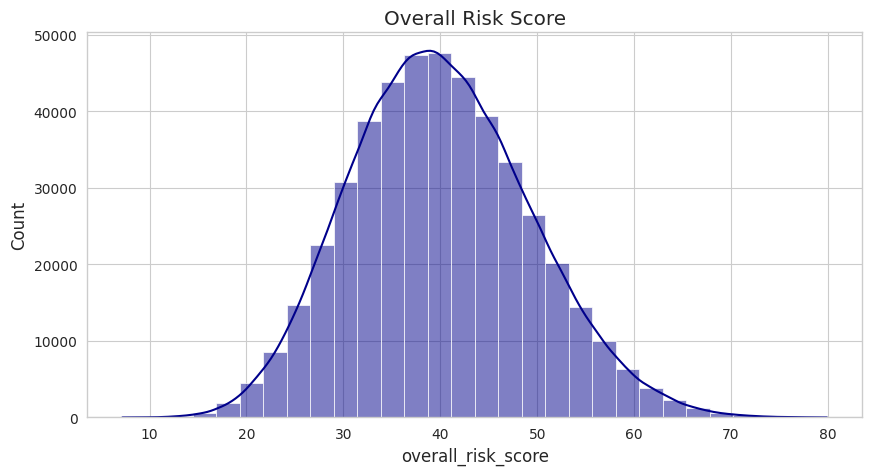

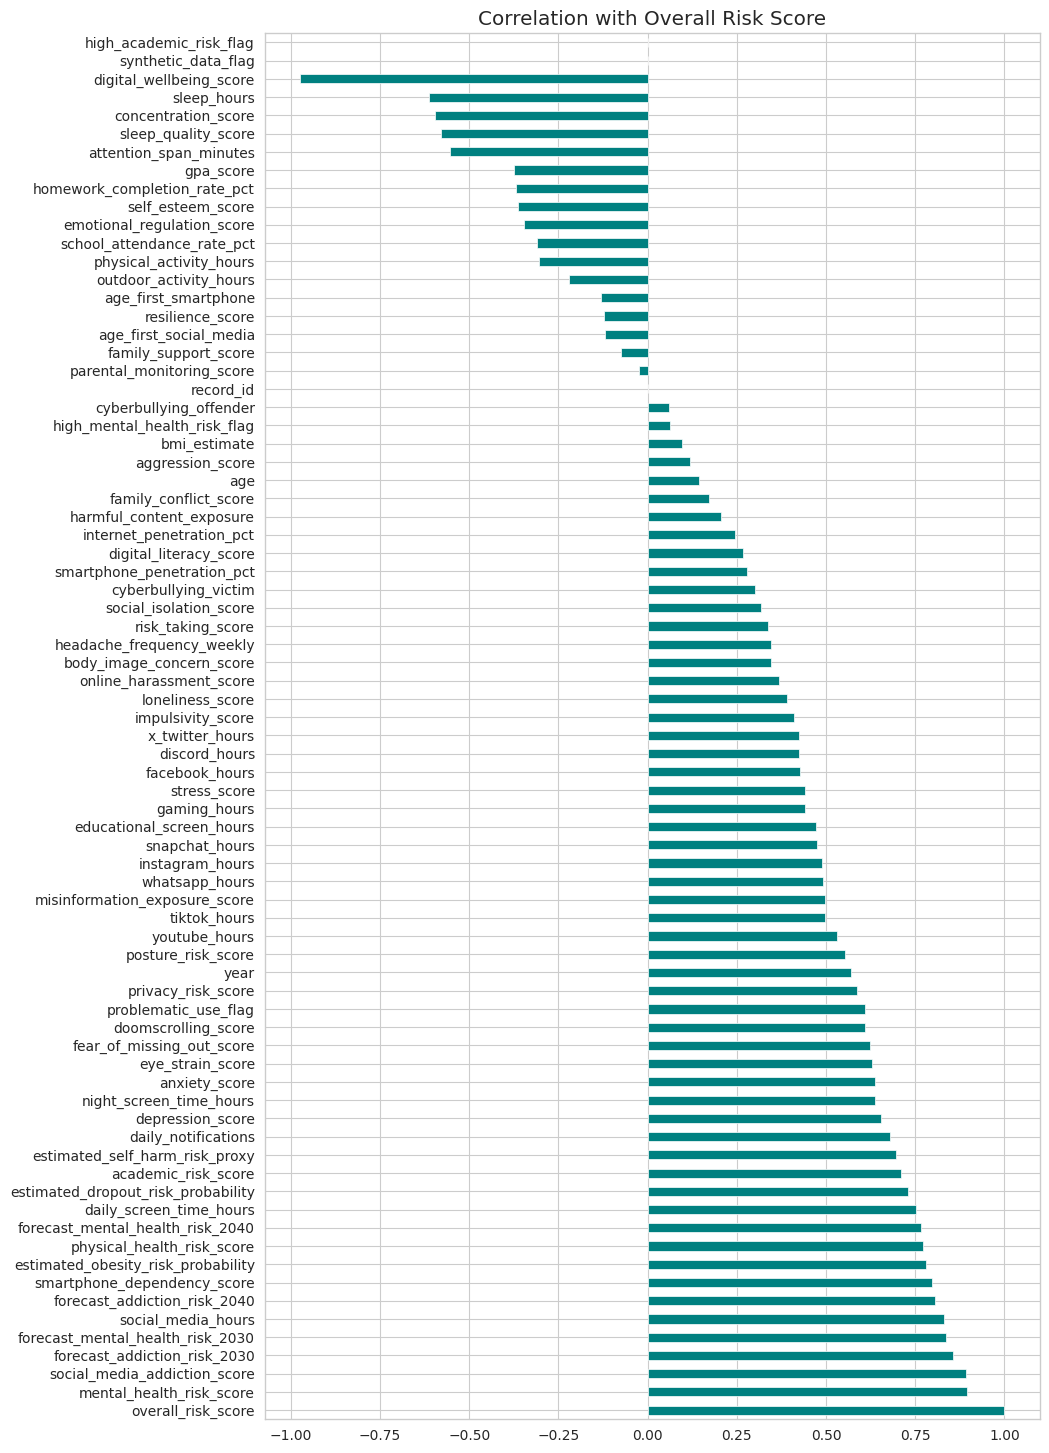

Visualization Completed Successfully!


In [14]:
# --------------------------------------------------------------
# Style
# --------------------------------------------------------------
plt.style.use("ggplot")
sns.set_style("whitegrid")

# --------------------------------------------------------------
# Dataset Information
# --------------------------------------------------------------
print(df.shape)
print(df.info())
print(df.describe(include='all'))

# ==============================================================
# 1. Missing Values
# ==============================================================
plt.figure(figsize=(18,6))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False)
plt.title("Missing Values Heatmap", fontsize=18)
plt.show()

# ==============================================================
# Separate Numerical and Categorical Columns
# ==============================================================
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

print("Numerical Columns :", len(num_cols))
print("Categorical Columns :", len(cat_cols))

# ==============================================================
# 2. Histograms
# ==============================================================
df[num_cols].hist(
    figsize=(30,30),
    bins=30,
    color='cornflowerblue',
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features", fontsize=25)
plt.show()

# ==============================================================
# 3. Boxplots
# ==============================================================
for col in num_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col],
        color=np.random.choice([
            'red','green','blue','orange','purple',
            'pink','cyan','gold','lime','magenta'
        ])
    )

    plt.title(col)
    plt.show()

# ==============================================================
# 4. Countplots
# ==============================================================
for col in cat_cols:

    plt.figure(figsize=(12,5))

    sns.countplot(
        data=df,
        x=col,
        palette='Set2'
    )

    plt.xticks(rotation=45)

    plt.title(f"{col} Distribution",fontsize=16)

    plt.show()

# ==============================================================
# 5. Correlation Heatmap
# ==============================================================
plt.figure(figsize=(28,22))

corr=df[num_cols].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=.5
)

plt.title("Correlation Heatmap",fontsize=25)

plt.show()

# ==============================================================
# 6. Pairplot (Important Columns)
# ==============================================================

important=[
'age',
'daily_screen_time_hours',
'social_media_hours',
'sleep_hours',
'anxiety_score',
'depression_score',
'overall_risk_score'
]

sns.pairplot(
    df[important],
    corner=True,
    palette='husl'
)

plt.show()

# ==============================================================
# 7. Risk Level Count
# ==============================================================
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='risk_level',
    palette='rocket'
)

plt.title("Risk Level")

plt.show()

# ==============================================================
# 8. Gender vs Risk Level
# ==============================================================
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='gender',
    hue='risk_level',
    palette='Dark2'
)

plt.title("Gender vs Risk Level")

plt.show()

# ==============================================================
# 9. Country Distribution
# ==============================================================
top=df.country.value_counts().head(15)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top.index,
    y=top.values,
    palette='tab20'
)

plt.xticks(rotation=45)

plt.title("Top Countries")

plt.show()

# ==============================================================
# 10. Continent Distribution
# ==============================================================
plt.figure(figsize=(8,6))

df.continent.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=sns.color_palette("pastel")
)

plt.ylabel("")

plt.title("Continent Distribution")

plt.show()

# ==============================================================
# 11. Age Distribution
# ==============================================================
plt.figure(figsize=(10,5))

sns.histplot(
    df.age,
    bins=25,
    color='orange',
    kde=True
)

plt.title("Age Distribution")

plt.show()

# ==============================================================
# 12. Screen Time vs Risk
# ==============================================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(8000),
    x='daily_screen_time_hours',
    y='overall_risk_score',
    hue='risk_level',
    palette='viridis'
)

plt.title("Daily Screen Time vs Overall Risk")

plt.show()

# ==============================================================
# 13. Screen Time Category
# ==============================================================
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='screen_time_category',
    palette='Spectral'
)

plt.show()

# ==============================================================
# 14. Sleep Category
# ==============================================================
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='sleep_category',
    palette='coolwarm'
)

plt.show()

# ==============================================================
# 15. GPA vs Risk
# ==============================================================
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x='risk_level',
    y='gpa_score',
    palette='Set3'
)

plt.show()

# ==============================================================
# 16. Anxiety Distribution
# ==============================================================
plt.figure(figsize=(10,5))

sns.kdeplot(
    df.anxiety_score,
    fill=True,
    color='red'
)

plt.title("Anxiety Score")

plt.show()

# ==============================================================
# 17. Depression Distribution
# ==============================================================
plt.figure(figsize=(10,5))

sns.kdeplot(
    df.depression_score,
    fill=True,
    color='purple'
)

plt.title("Depression Score")

plt.show()

# ==============================================================
# 18. Social Media Hours by Gender
# ==============================================================
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='gender',
    y='social_media_hours',
    palette='Accent'
)

plt.show()

# ==============================================================
# 19. Academic Risk Distribution
# ==============================================================
plt.figure(figsize=(10,5))

sns.histplot(
    df.academic_risk_score,
    bins=25,
    color='green'
)

plt.show()

# ==============================================================
# 20. Overall Risk Distribution
# ==============================================================
plt.figure(figsize=(10,5))

sns.histplot(
    df.overall_risk_score,
    bins=30,
    kde=True,
    color='darkblue'
)

plt.title("Overall Risk Score")

plt.show()

# ==============================================================
# 21. Correlation with Overall Risk
# ==============================================================
corr_target = (
    df[num_cols]
    .corr()['overall_risk_score']
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,18))

corr_target.plot(
    kind='barh',
    color='teal'
)

plt.title("Correlation with Overall Risk Score")

plt.show()

print("Visualization Completed Successfully!")

## Feature engineering

In [15]:
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.preprocessing import label_binarize




leakage_columns = [
    "overall_risk_score",
    "mental_health_risk_score",
    "physical_health_risk_score",
    "estimated_dropout_risk_probability",
    "estimated_obesity_risk_probability",
    "estimated_self_harm_risk_proxy",
    "forecast_addiction_risk_2030",
    "forecast_addiction_risk_2040",
    "forecast_mental_health_risk_2030",
    "forecast_mental_health_risk_2040",
    "high_mental_health_risk_flag",
    "high_academic_risk_flag",
    "problematic_use_flag"
]

df = df.drop(columns=leakage_columns)

# ----------------------------------------------------------
# Target
# ----------------------------------------------------------

target = "risk_level"

X = df.drop(columns=[target])

y = df[target]

# ----------------------------------------------------------
# Encode Target
# ----------------------------------------------------------

le = LabelEncoder()

y = le.fit_transform(y)

# ----------------------------------------------------------
# Numerical and Categorical Columns
# ----------------------------------------------------------

num_cols = X.select_dtypes(include=["int64","float64"]).columns

cat_cols = X.select_dtypes(include=["object","bool"]).columns

# ----------------------------------------------------------
# Preprocessing
# ----------------------------------------------------------

numeric_transformer = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num",numeric_transformer,num_cols),
    ("cat",categorical_transformer,cat_cols)
])

# ----------------------------------------------------------
# Train Test Split
# ----------------------------------------------------------

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(371797, 73)
(92950, 73)


In [16]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=2000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(random_state=42),

    "Naive Bayes":
    GaussianNB(),

    "KNN":
    KNeighborsClassifier(),

    "SVM":
    SVC(
        probability=True,
        random_state=42
    )
}

Logistic Regression
Accuracy : 0.9548
              precision    recall  f1-score   support

        High       0.92      0.90      0.91      5613
         Low       0.94      0.94      0.94     28566
    Moderate       0.96      0.97      0.96     58760
      Severe       0.00      0.00      0.00        11

    accuracy                           0.95     92950
   macro avg       0.71      0.70      0.70     92950
weighted avg       0.95      0.95      0.95     92950



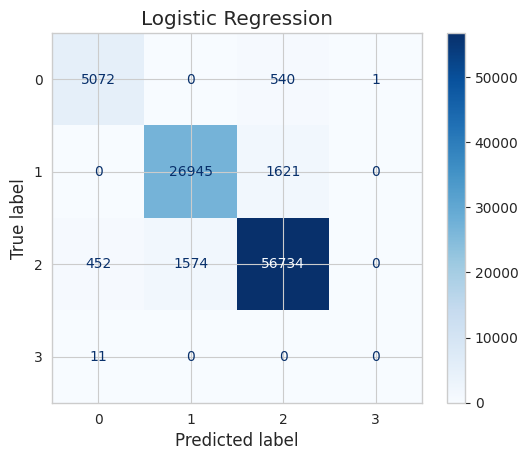

Decision Tree
Accuracy : 0.9235
              precision    recall  f1-score   support

        High       0.84      0.85      0.85      5613
         Low       0.90      0.91      0.91     28566
    Moderate       0.94      0.94      0.94     58760
      Severe       0.22      0.18      0.20        11

    accuracy                           0.92     92950
   macro avg       0.73      0.72      0.72     92950
weighted avg       0.92      0.92      0.92     92950



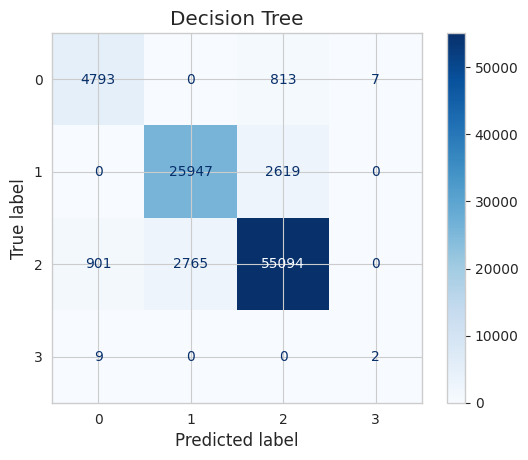

Random Forest
Accuracy : 0.9448
              precision    recall  f1-score   support

        High       0.92      0.84      0.88      5613
         Low       0.94      0.93      0.93     28566
    Moderate       0.95      0.96      0.96     58760
      Severe       0.00      0.00      0.00        11

    accuracy                           0.94     92950
   macro avg       0.70      0.68      0.69     92950
weighted avg       0.94      0.94      0.94     92950



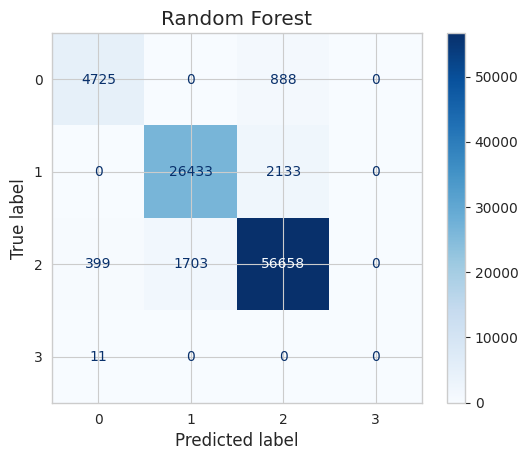

Gradient Boosting
Accuracy : 0.9528
              precision    recall  f1-score   support

        High       0.91      0.89      0.90      5613
         Low       0.95      0.94      0.94     28566
    Moderate       0.96      0.97      0.96     58760
      Severe       0.00      0.00      0.00        11

    accuracy                           0.95     92950
   macro avg       0.70      0.70      0.70     92950
weighted avg       0.95      0.95      0.95     92950



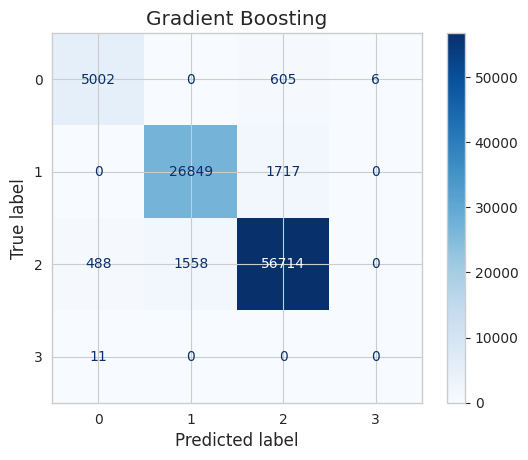

Naive Bayes
Accuracy : 0.7156
              precision    recall  f1-score   support

        High       0.28      0.73      0.41      5613
         Low       0.78      0.88      0.83     28566
    Moderate       0.92      0.63      0.75     58760
      Severe       0.00      0.27      0.00        11

    accuracy                           0.72     92950
   macro avg       0.49      0.63      0.50     92950
weighted avg       0.83      0.72      0.75     92950



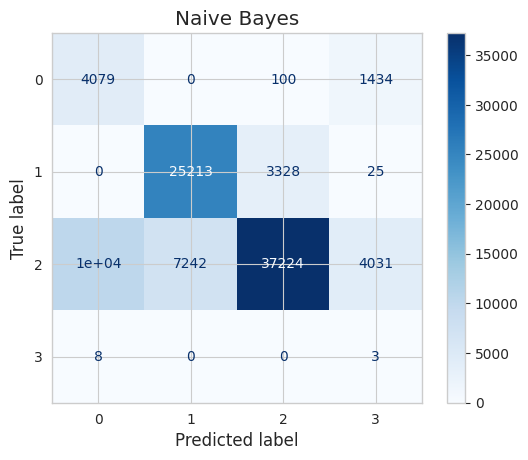

KNN
Accuracy : 0.8926
              precision    recall  f1-score   support

        High       0.89      0.61      0.72      5613
         Low       0.87      0.88      0.87     28566
    Moderate       0.91      0.93      0.92     58760
      Severe       0.00      0.00      0.00        11

    accuracy                           0.89     92950
   macro avg       0.66      0.60      0.63     92950
weighted avg       0.89      0.89      0.89     92950



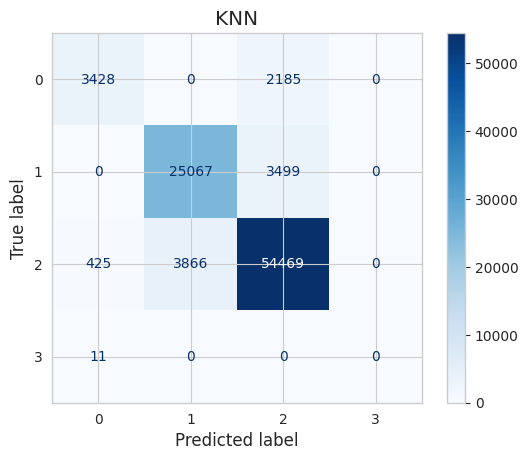

SVM
Accuracy : 0.9524
              precision    recall  f1-score   support

        High       0.91      0.89      0.90      5613
         Low       0.94      0.94      0.94     28566
    Moderate       0.96      0.96      0.96     58760
      Severe       0.00      0.00      0.00        11

    accuracy                           0.95     92950
   macro avg       0.70      0.70      0.70     92950
weighted avg       0.95      0.95      0.95     92950



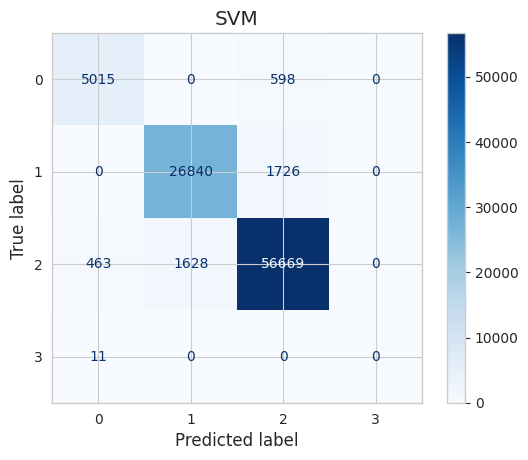

In [17]:
results=[]

for name,model in models.items():

    print("="*60)
    print(name)

    pipeline=Pipeline([
        ("preprocessor",preprocessor),
        ("model",model)
    ])

    pipeline.fit(X_train,y_train)

    pred=pipeline.predict(X_test)

    acc=accuracy_score(y_test,pred)

    print("Accuracy :",round(acc,4))

    print(classification_report(
        y_test,
        pred,
        target_names=le.classes_
    ))

    results.append([name,acc])

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        cmap="Blues"
    )

    plt.title(name)

    plt.show()

                 Model  Accuracy
0  Logistic Regression  0.954825
3    Gradient Boosting  0.952824
6                  SVM  0.952383
2        Random Forest  0.944766
1        Decision Tree  0.923464
5                  KNN  0.892566
4          Naive Bayes  0.715643


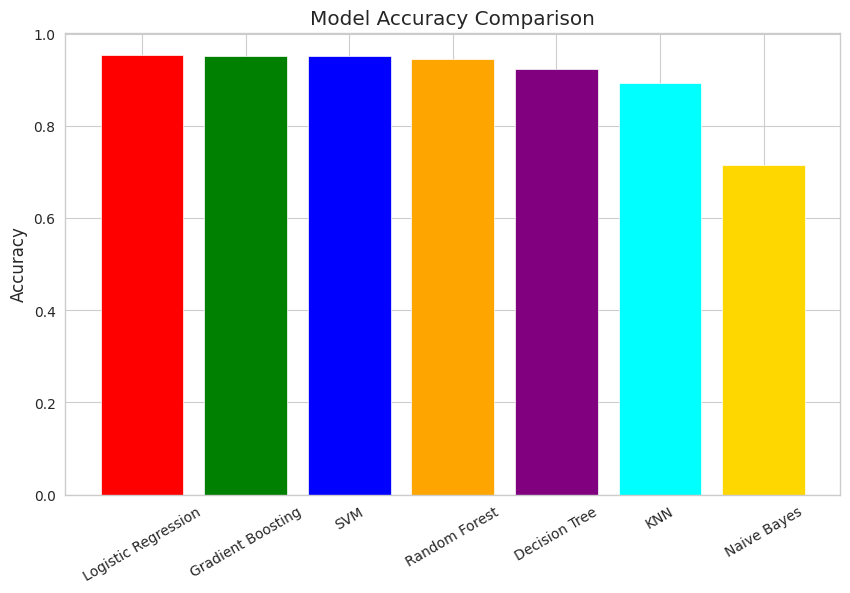

In [18]:
results=pd.DataFrame(
    results,
    columns=["Model","Accuracy"]
)

results=results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

plt.figure(figsize=(10,6))

plt.bar(
    results["Model"],
    results["Accuracy"],
    color=[
        "red",
        "green",
        "blue",
        "orange",
        "purple",
        "cyan",
        "gold"
    ]
)

plt.xticks(rotation=30)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

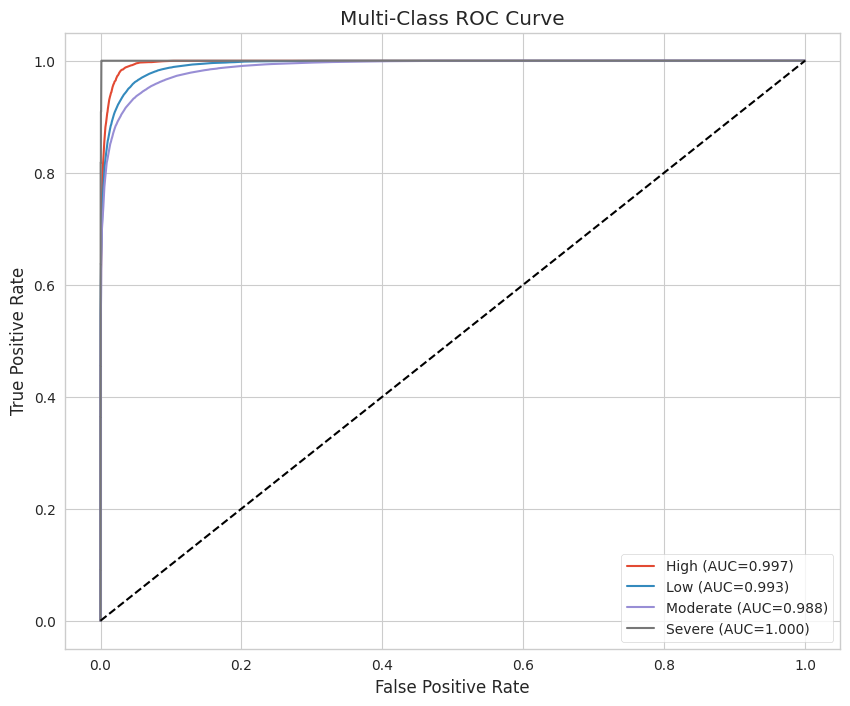

In [19]:
from sklearn.preprocessing import label_binarize

classes=np.unique(y)

y_test_bin=label_binarize(y_test,classes=classes)

best_model=Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

best_model.fit(X_train,y_train)

prob=best_model.predict_proba(X_test)

plt.figure(figsize=(10,8))

for i in range(len(classes)):

    fpr,tpr,_=roc_curve(
        y_test_bin[:,i],
        prob[:,i]
    )

    roc_auc=auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{le.classes_[i]} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Multi-Class ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

## Thank you...pls upvote!!!!!!!!!!!!!